#  MULTI-MODEL AUDIO PROBE & PERTURBATION EVALUATION

 Evaluates speaker identity, gender, semantic content,
 and emotion probes at P1 (encoder) and P2 (adapter)
 across multiple open-source LALMs, and measures how
 each acoustic perturbation degrades those probes.

###  Models supported (run ONE at a time per session):
   1. fixie-ai/ultravox-v0_5-llama-3_2-1b   (baseline, Whisper-med + MLP)
   2. Qwen/Qwen2-Audio-7B-Instruct           (Whisper-large + Linear)
   3. microsoft/Phi-4-multimodal-instruct    (custom encoder + MLP)
   4. bytedance/SALMONN                      (Whisper+BEATs dual encoder + Q-Former)
   5. WillHeld/diva-llama-3-v0-8b            (Whisper-large + Linear, LLaMA-3-8B)
   6. google/gemma-3n-E4B-it                 (USM audio encoder + Gemma-3n)
   7. openbmb/MiniCPM-o-2_6                  (Whisper-med + MLP, compact)

###  Probe tasks:
   • Emotion          (6-way classification on CREMA-D)
   • Speaker Identity (91-way on CREMA-D)
   • Gender           (2-way, from CREMA-D demographics)
   • Semantic Content (12-way sentence ID on CREMA-D)

###  Perturbation conditions tested on probe tasks:
   clean, pitch_up(+4st), pitch_down(-4st),
   speed_fast(1.3x), speed_slow(0.75x), noise, whisper

###  Output:
   multi_model_probe_results.json   — all numbers
   multi_model_probe_results.md     — formatted tables



## Cell 0: CONFIGURATION — set before running


In [1]:

ACTIVE_MODEL = 'ultravox'
QUANTIZE_4BIT = True

CREMA_DIR    = r'C:\Users\acer\Downloads\AudioWAV' 
# r"C:\Users\acer\Downloads\AudioWAV"

# Path to CREMA-D demographics CSV (optional — enables gender probe)
# Columns expected: ActorID, Age, Sex, Race, Ethnicity
CREMA_DEMOG  = r'C:\Users\acer\Downloads\VideoDemographics.csv'

N_CLIPS =2000
# N_CLIPS      = 7442

PERTURBATIONS = ['clean', 'pitch_up', 'pitch_down',
                 'speed_fast', 'speed_slow', 'noise', 'whisper']



## Cell 1: Imports


In [ ]:
import os, re, json
import numpy as np
import torch
import librosa
import soundfile as sf
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Dict, List
from scipy.signal import butter, filtfilt
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

from transformers import AutoModel, AutoProcessor

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


c:\Users\acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


: 

## Cell 2: Model configurations


In [15]:
# ── CELL 2  Model configurations ───────────────────────────
#
# Each config specifies where to register hooks for P1 and P2.
# Hook paths use dotted notation; list items via [N] or [-1].
#
# HOW TO FIND HOOK PATHS FOR A NEW MODEL:
#   Run inspect_model(model) (Cell 4 utility) after loading.
#   It prints all named modules — find the last encoder layer
#   and the projection/adapter module.
#
# IMPORTANT: some models call projectors via .forward() rather
# than .__call__(), bypassing PyTorch hooks.  In that case,
# hook a SUBMODULE inside the projector (e.g. ln_post, fc2).
# The comment field documents which submodule to fall back to.

@dataclass
class ModelConfig:
    model_id:       str
    display_name:   str
    # P1: primary audio encoder last layer
    p1_path:        str
    # P2: adapter/projector output (hook submodule if .forward() bypass)
    p2_path:        str
    p2_fallback:    Optional[str]       = None  # if main path uses .forward()
    audio_token:    str                 = '<|audio|>'
    # Additional P1 paths for dual-encoder models (e.g. SALMONN's BEATs)
    # Format: {'P1_beats': 'beats.encoder.layers[-1]', ...}
    p1_extra_paths: Dict                = field(default_factory=dict)
    # LLM layer paths (early / mid / late)
    llm_early_path: Optional[str]       = None
    llm_mid_path:   Optional[str]       = None
    llm_late_path:  Optional[str]       = None
    # Architecture metadata (for the comparison table)
    encoder_name:   str                 = ''
    adapter_type:   str                 = ''
    llm_name:       str                 = ''
    d_enc:          int                 = -1
    d_llm:          int                 = -1
    n_llm_layers:   int                 = -1
    # Load kwargs
    dtype:          str                 = 'float16'
    trust_remote:   bool                = False
    # Some models need a specific class instead of AutoModel
    # e.g. 'transformers.AutoModelForCausalLM'
    load_class:     Optional[str]       = None
    extra_load_kwargs: Dict             = field(default_factory=dict)

    def llm_paths(self):
        return {k: v for k, v in {
            'LLM_early': self.llm_early_path,
            'LLM_mid':   self.llm_mid_path,
            'LLM_late':  self.llm_late_path,
        }.items() if v is not None}

    def all_p1_paths(self):
        """Returns all P1 hook paths: primary + any extra (dual encoders)."""
        paths = {'P1': self.p1_path}
        paths.update(self.p1_extra_paths)
        return paths


MODEL_CONFIGS = {

    # ── Ultravox v0.5 ─────────────────────────────────────
    # Encoder  : Whisper-medium  (d=1024)
    # Adapter  : StackAudioFrames MLP — calls .forward() directly
    #            → hook on ln_post (last submodule inside projector)
    # LLM      : LLaMA-3.2-1B (16 layers, d=2048)
    'ultravox': ModelConfig(
        model_id       = 'fixie-ai/ultravox-v0_5-llama-3_2-1b',
        display_name   = 'Ultravox-v0.5 (LLaMA-3.2-1B)',
        p1_path        = 'audio_tower.layers[-1]',
        p2_path        = 'multi_modal_projector',
        p2_fallback    = 'multi_modal_projector.ln_post',
        llm_early_path = 'language_model.model.layers[4]',
        llm_mid_path   = 'language_model.model.layers[8]',
        llm_late_path  = 'language_model.model.layers[14]',
        encoder_name   = 'Whisper-medium',
        adapter_type   = 'MLP (StackAudioFrames)',
        llm_name       = 'LLaMA-3.2-1B',
        d_enc=1024, d_llm=2048, n_llm_layers=16,
        trust_remote   = True,
    ),

    # ── Qwen2-Audio-7B ────────────────────────────────────
    # Encoder  : Whisper-large-v2  (d=1280)
    # Adapter  : audio_projection — Linear(1280, 3584) + LayerNorm
    #            (usually hooks correctly via __call__)
    # LLM      : Qwen2-7B (28 layers, d=3584)
    # NOTE: requires ~14GB VRAM; use 4-bit quant on T4:
    #   extra_load_kwargs={'load_in_4bit': True}
    'qwen2': ModelConfig(
        model_id       = 'Qwen/Qwen2-Audio-7B-Instruct',
        display_name   = 'Qwen2-Audio-7B',
        p1_path        = 'model.audio_tower.layers[-1]',
        p2_path        = 'model.multi_modal_projector',
        p2_fallback    = None,
        llm_early_path = 'model.language_model.layers[4]',
        llm_mid_path   = 'model.language_model.layers[14]',
        llm_late_path  = 'model.language_model.layers[24]',
        audio_token    = '<|AUDIO|>',
        encoder_name   = 'Whisper-large-v2',
        adapter_type   = 'Linear + LayerNorm',
        llm_name       = 'Qwen2-7B',
        d_enc=1280, d_llm=3584, n_llm_layers=28,
        trust_remote   = False,
        load_class     = 'transformers.Qwen2AudioForConditionalGeneration',
    ),

    # ── Phi-4-multimodal ─────────────────────────────────
    # Encoder  : Custom Phi audio encoder
    # Adapter  : audio_projection MLP
    # LLM      : Phi-4 (3.8B, 32 layers, d=3072)
    # NOTE: hook paths need verification via inspect_model()
    #       The paths below are best-effort from known architecture.
    'phi4': ModelConfig(
        model_id       = 'microsoft/Phi-4-multimodal-instruct',
        display_name   = 'Phi-4-multimodal (3.8B)',
        p1_path        = 'model.audio_embed_tokens.encoder.layers[-1]',
        p2_path        = 'model.audio_embed_tokens.projection',
        p2_fallback    = 'model.audio_embed_tokens.projection.layers[-1]',
        llm_early_path = 'model.layers[4]',
        llm_mid_path   = 'model.layers[16]',
        llm_late_path  = 'model.layers[28]',
        encoder_name   = 'Phi-audio-encoder',
        adapter_type   = 'MLP projector',
        llm_name       = 'Phi-4 (3.8B)',
        d_enc=-1, d_llm=3072, n_llm_layers=32,
        trust_remote   = True,
    ),

    # ── SALMONN-7B ───────────────────────────────────────
    # UNIQUE: dual audio encoder (Whisper-large-v2 + BEATs)
    #   Whisper captures ASR/speech features  (d=1280)
    #   BEATs captures non-speech audio events (d=768)
    #   Both feed a shared Q-Former that compresses to 32 query tokens
    # Adapter  : Q-Former (BERT-style cross-attention)
    #            → the most aggressive compression of any model here
    # LLM      : Vicuna-7B or LLaMA-2-7B (28 layers, d=4096)
    # Provides TWO P1 points: P1_whisper and P1_beats
    # P1_beats probes non-speech content (tone, affect, background)
    # P1_whisper probes speech content (words, prosody)
    # KEY PREDICTION: BEATs-derived features (paralinguistic) should
    # drop MORE at P2 than Whisper features (semantic) — if true,
    # Q-Former selectively discards non-speech signal.
    # VRAM: ~14GB. Use load_in_4bit=True on T4.
    # NOTE: verify hook paths with inspect_model() — SALMONN's module
    #       naming varies between the original and HF-uploaded versions.
    'salmonn': ModelConfig(
        model_id        = 'tsinghua-ee/SALMONN-7B',
        display_name    = 'SALMONN-7B (Whisper+BEATs+Q-Former)',
        p1_path         = 'speech_encoder.model.encoder.layers[-1]',
        p1_extra_paths  = {
            'P1_beats': 'beats.encoder.layers[-1]',   # non-speech encoder
        },
        p2_path         = 'audio_Qformer.bert.encoder.layer[-1]',
        p2_fallback     = 'speech_llama_proj',
        llm_early_path  = 'llama_model.model.layers[4]',
        llm_mid_path    = 'llama_model.model.layers[14]',
        llm_late_path   = 'llama_model.model.layers[24]',
        encoder_name    = 'Whisper-large-v2 + BEATs (dual)',
        adapter_type    = 'Q-Former (32 query tokens)',
        llm_name        = 'Vicuna-7B',
        d_enc=1280, d_llm=4096, n_llm_layers=32,
        trust_remote    = True,
        extra_load_kwargs = {'load_in_4bit': False},   # set True on T4
    ),

    # ── DiVA (Distilled Voice Adapter) ───────────────────
    # Encoder  : Whisper-large-v2  (d=1280)
    # Adapter  : Linear projection — trained via DISTILLATION
    #            (adapter output is trained to match LLaMA text embeddings
    #            of the Whisper transcript, NOT end-to-end fine-tuned)
    # LLM      : LLaMA-3-8B (32 layers, d=4096)
    # UNIQUE PROPERTY: because the adapter is distillation-trained to
    # mimic text embeddings, P2 should be CLOSER to text space than any
    # other model. Exp 3 (transcript equivalence) is the key test here —
    # DiVA should show a much larger self-similarity gap than Ultravox.
    # RESEARCH VALUE: directly tests whether "collapsing to text space"
    # is what causes safety bypass (DiVA does this by design — does it
    # have worse safety than models that don't?).
    # VRAM: ~16GB in fp16. Use load_in_4bit=True on T4.
    'diva': ModelConfig(
        model_id        = 'WillHeld/diva-llama-3-v0-8b',
        display_name    = 'DiVA (Whisper-large + LLaMA-3-8B)',
        p1_path         = 'whisper.encoder.layers[-1]',
        p2_path         = 'projection',
        p2_fallback     = None,
        llm_early_path  = 'llm.model.layers[4]',
        llm_mid_path    = 'llm.model.layers[16]',
        llm_late_path   = 'llm.model.layers[28]',
        encoder_name    = 'Whisper-large-v2',
        adapter_type    = 'Linear (distillation-trained)',
        llm_name        = 'LLaMA-3-8B',
        d_enc=1280, d_llm=4096, n_llm_layers=32,
        trust_remote    = True,
        extra_load_kwargs = {'load_in_4bit': False},   # set True on T4
    ),

    # ── Gemma-3n-E4B ─────────────────────────────────────
    # Encoder  : Universal Speech Model (USM-based) — NOT Whisper
    #            This is the only model in the suite with a
    #            non-Whisper encoder, making it crucial for the
    #            cross-encoder comparison.
    # Adapter  : MatFormer-style projection integrated into model
    # LLM      : Gemma-3n-E4B (effective 4B, elastic architecture)
    # KEY PREDICTION: if information loss patterns replicate on a
    # completely different encoder family, the bottleneck is a
    # structural property of multimodal projection, not Whisper-specific.
    # VRAM: ~8GB in bfloat16.
    # NOTE: Gemma-3n uses bfloat16 natively. Audio input may need
    # different processor API — check processor documentation.
    # Hook paths are best-effort; verify with inspect_model().
    'gemma3n': ModelConfig(
        model_id        = 'google/gemma-3n-E4B-it',
        display_name    = 'Gemma-3n-E4B (USM encoder)',
        p1_path         = 'model.audio_encoder.encoder.layers[-1]',
        p2_path         = 'model.audio_tower.projection',
        p2_fallback     = 'model.audio_tower.projection.linear',
        llm_early_path  = 'model.layers[4]',
        llm_mid_path    = 'model.layers[18]',
        llm_late_path   = 'model.layers[32]',
        encoder_name    = 'USM (Universal Speech Model)',
        adapter_type    = 'MatFormer projection',
        llm_name        = 'Gemma-3n (4B)',
        d_enc=-1, d_llm=2560, n_llm_layers=36,
        dtype           = 'bfloat16',
        trust_remote    = False,
    ),

    # ── MiniCPM-o-2.6 ────────────────────────────────────
    # Encoder  : Whisper-medium  (d=1024) — same as Ultravox
    #            Direct apples-to-apples comparison for adapter effects
    # Adapter  : MLP projector (similar depth to Ultravox)
    # LLM      : MiniCPM-3 (3.8B, 40 layers, d=2304)
    # RESEARCH VALUE: same encoder as Ultravox, different LLM family.
    # If probe results differ, the difference is LLM-driven, not encoder.
    # If probe results match, encoder architecture is the dominant factor.
    # VRAM: ~6GB. Fits on T4 without quantization.
    # NOTE: MiniCPM-o is omni-modal (text+image+audio+video). The audio
    # pathway hooks are within model.apm (audio perception module).
    # Verify exact paths with inspect_model().
    'minicpm': ModelConfig(
        model_id        = 'openbmb/MiniCPM-o-2_6',
        display_name    = 'MiniCPM-o-2.6 (Whisper-med + MiniCPM-3)',
        p1_path         = 'model.apm.encoder.layers[-1]',
        p2_path         = 'model.apm.projection',
        p2_fallback     = 'model.apm.projection.linear_out',
        llm_early_path  = 'model.layers[4]',
        llm_mid_path    = 'model.layers[20]',
        llm_late_path   = 'model.layers[36]',
        encoder_name    = 'Whisper-medium',
        adapter_type    = 'MLP projector',
        llm_name        = 'MiniCPM-3 (3.8B)',
        d_enc=1024, d_llm=2304, n_llm_layers=40,
        trust_remote    = True,
    ),
    'voxtral_mini': ModelConfig(
    model_id        = 'mistralai/Voxtral-Mini-3B-2507',
    display_name    = 'Voxtral-Mini-3B (Whisper + Mistral)',
    p1_path         = 'model.audio_tower.layers[-1]',
    p2_path         = 'model.multi_modal_projector',
    p2_fallback     = 'model.multi_modal_projector.linear',
    llm_early_path  = 'model.layers[4]',
    llm_mid_path    = 'model.layers[14]',
    llm_late_path   = 'model.layers[24]',
    encoder_name    = 'Whisper (Voxtral variant)',
    adapter_type    = 'MLP projector (GELU)',
    llm_name        = 'Ministral-3B',
    d_enc=-1, d_llm=3072, n_llm_layers=28,
    dtype           = 'bfloat16',
    # NOTE: use VoxtralForConditionalGeneration, not AutoModel
    load_class      = 'transformers.VoxtralForConditionalGeneration',
    trust_remote    = False,
),
}


In [4]:
!pip install git+https://github.com/huggingface/transformers.git

  Cloning https://github.com/huggingface/transformers.git to C:\Users\acer\AppData\Local\Temp\pip-req-build-93016tdw
  Resolved https://github.com/huggingface/transformers.git to commit eee480d59810135f45280f8db99f14d0136bed82
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for transformers: filename=transformers-5.14.0.dev0-py3-none-any.whl size=12723220 sha256=4413d6254fcff0a4a629a4d04a3eec7cebf6bb6a5ab7198a8aa2424c8b1f5828
  Stored in directory: C:\Users\acer\AppData\Local\Temp\pip-ephem-wheel-cache-_cjfm_tk\wheels\54\cb\3f\83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.1

  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git 'C:\Users\acer\AppData\Local\Temp\pip-req-build-93016tdw'
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
docling-ibm-models 3.10.3 requires huggingface_hub<1,>=0.23, but you have huggingface-hub 1.21.0 which is incompatible.
docling-ibm-models 3.10.3 requires transformers<5.0.0,>=4.42.0, but you have transformers 5.14.0.dev0 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install bitsandbytes accelerate


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 3: Load model


In [6]:
cfg = MODEL_CONFIGS[ACTIVE_MODEL]
print(f'Loading {cfg.display_name} ...')

dtype_map = {'float16': torch.float16, 'bfloat16': torch.bfloat16,
             'float32': torch.float32}
load_kwargs = dict(
    trust_remote_code = cfg.trust_remote,
    low_cpu_mem_usage = True,
    device_map        = {'': 0},
    **cfg.extra_load_kwargs,
)

if QUANTIZE_4BIT:
    print("Using 4-bit quantization to fit in low VRAM environment...")
    from transformers import BitsAndBytesConfig
    load_kwargs['quantization_config'] = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=dtype_map[cfg.dtype],
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )
    load_kwargs['dtype'] = dtype_map[cfg.dtype]
    load_kwargs['torch_dtype'] = dtype_map[cfg.dtype]
else:
    load_kwargs['dtype'] = dtype_map[cfg.dtype]

if cfg.load_class:
    import importlib
    module_name, class_name = cfg.load_class.rsplit('.', 1)
    loader = getattr(importlib.import_module(module_name), class_name)
else:
    loader = AutoModel

model     = loader.from_pretrained(cfg.model_id, **load_kwargs)
processor = AutoProcessor.from_pretrained(cfg.model_id,
                                          trust_remote_code=cfg.trust_remote)
model.eval()
print(f'Loaded. Parameters: {sum(p.numel() for p in model.parameters())/1e9:.2f}B')

if ACTIVE_MODEL == 'salmonn' and cfg.p1_extra_paths:
    print('SALMONN dual-encoder check:')
    for name, path in cfg.all_p1_paths().items():
        try:
            resolve_module(model, path)
            print(f'  ✓ {name} → {path}')
        except Exception as e:
            print(f'  ✗ {name} → {path}  [ERROR: {e}]')
            print('    → Run inspect_model(model) to find the correct path.')


Loading Voxtral-Mini-3B (Whisper + Mistral) ...
Using 4-bit quantization to fit in low VRAM environment...


W0706 23:06:07.716000 100172 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1996.34it/s]


OSError: Insufficient system resources exist to complete the requested service. (os error 1450)

## Cell 4: Utilities


In [16]:
def inspect_model(model, max_lines=120):
    
    lines = list(model.named_modules())
    for i, (name, mod) in enumerate(lines[:max_lines]):
        print(f'{name:<60} {type(mod).__name__}')
    if len(lines) > max_lines:
        print(f'... ({len(lines) - max_lines} more modules)')


def resolve_module(model, path_str):
    parts = re.split(r'\.(?![^\[]*\])', path_str)
    m = model
    for part in parts:
        idx_m = re.match(r'(.+)\[(-?\d+)\]', part)
        if idx_m:
            attr, idx = idx_m.group(1), int(idx_m.group(2))
            m = getattr(m, attr)[idx]
        else:
            m = getattr(m, part)
    return m


class SingleShotCapture:
    def __init__(self, pool='mean'):
        self.data   = None
        self._fired = False
        self.pool   = pool  # 'mean' or 'last'

    def hook_fn(self, module, inp, output):
        if self._fired:
            return
        out = output[0] if isinstance(output, tuple) else output
        if out is None:
            return
        self.data   = out.detach().cpu().float()
        self._fired = True

    def reset(self):
        self.data   = None
        self._fired = False

    def pooled(self):
        if self.data is None:
            return None
        t = self.data.squeeze(0)   # → [T, D] or [D]
        if t.dim() == 1:
            return t.numpy()
        return (t.mean(0) if self.pool == 'mean' else t[-1]).numpy()


## Cell 5: Audio loading + perturbations


In [17]:
def load_audio(path, sr=16000):
    y, _ = librosa.load(str(path), sr=sr, mono=True)
    return y.astype(np.float32)

def apply_perturbation(y, sr, condition):
    if condition == 'clean':
        return y
    if condition == 'pitch_up':
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=4)
    if condition == 'pitch_down':
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=-4)
    if condition == 'speed_fast':
        return librosa.effects.time_stretch(y, rate=1.3)
    if condition == 'speed_slow':
        return librosa.effects.time_stretch(y, rate=0.75)
    if condition == 'noise':
        noise = np.random.randn(len(y)).astype(np.float32) * 0.02
        return np.clip(y + noise, -1.0, 1.0)
    if condition == 'whisper':
        b, a = butter(4, 300 / (sr / 2), btype='high')
        y_hp = filtfilt(b, a, y).astype(np.float32)
        return np.clip(y_hp + np.random.randn(len(y)).astype(np.float32)*0.01,
                       -1.0, 1.0)
    raise ValueError(f'Unknown condition: {condition}')


## Cell 6: CREMA-D loading + label extraction


In [18]:


EMOTION_MAP  = {'ANG':0,'DIS':1,'FEA':2,'HAP':3,'NEU':4,'SAD':5}
SENTENCE_MAP = {s:i for i,s in enumerate(
    ['IEO','TIE','IOM','IWW','TAI','MTI','IWL','ITH','DFA','ITS','TSI','WSI'])}

MALE_ACTORS = {
    1001,1002,1003,1004,1007,1008,1009,1010,1011,1012,
    1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,
    1023,1024,1025,1026,1027,1028,1029,1030,1031,1032,
    1033,1034,1043,1044,1045,1046,1047,1048,1049,1050,
    1051,1052,1053,1054,1055,1056,1057,1058,
}  # remaining 43 actors are Female

def load_gender_map(demog_csv):
    # load sex labels from VideoDemographics.csv if it exists.
    if not Path(demog_csv).exists():
        return None
    import csv
    gender = {}
    with open(demog_csv) as f:
        reader = csv.DictReader(f)
        for row in reader:
            aid = int(row['ActorID'])
            gender[aid] = 0 if row['Sex'].strip().upper().startswith('M') else 1
    return gender

def load_crema_metadata(crema_dir, demog_csv=None, n_clips=None):
    crema_path = Path(crema_dir)
    files      = sorted(crema_path.glob('*.wav'))[:n_clips]
    if not files:
        raise FileNotFoundError(f'No .wav files found in {crema_dir}')

    gender_map = load_gender_map(demog_csv) if demog_csv else None

    meta = []
    for f in files:
        parts = f.stem.split('_')
        if len(parts) < 3:
            continue
        actor_id = int(parts[0])
        sentence = parts[1]
        emotion  = parts[2]
        if emotion not in EMOTION_MAP or sentence not in SENTENCE_MAP:
            continue
        gender = -1
        if gender_map and actor_id in gender_map:
            gender = gender_map[actor_id]
        elif gender_map is None:
            gender = 0 if actor_id in MALE_ACTORS else 1
        meta.append({
            'path':     f,
            'actor_id': actor_id,
            'speaker':  actor_id - 1001,          # 0-indexed (0–90)
            'sentence': SENTENCE_MAP[sentence],
            'emotion':  EMOTION_MAP[emotion],
            'gender':   gender,
        })
    print(f'Loaded metadata for {len(meta)} CREMA-D clips.')
    return meta

crema_meta = load_crema_metadata(CREMA_DIR, CREMA_DEMOG, N_CLIPS)


Loaded metadata for 2000 CREMA-D clips.


## Cell 7: Hook registration


In [ ]:
def register_hooks(model, cfg):
    
    captures = {}
    handles  = []

    def _add(name, path):
        try:
            cap  = SingleShotCapture()
            mod  = resolve_module(model, path)
            h    = mod.register_forward_hook(cap.hook_fn)
            captures[name] = cap
            handles.append(h)
        except Exception as e:
            print(f'  [HOOK WARNING] Could not register {name} at "{path}": {e}')
            print(f'  Run inspect_model(model) to find the correct path.')

    # Register all P1 paths (primary + any extra for dual-encoder models)
    for p1_name, p1_path in cfg.all_p1_paths().items():
        _add(p1_name, p1_path)

    _add('P2', cfg.p2_path)
    if cfg.p2_fallback:
        _add('P2_fallback', cfg.p2_fallback)

    for name, path in cfg.llm_paths().items():
        _add(name, path)

    return captures, handles


def remove_hooks(handles):
    for h in handles:
        h.remove()


def get_valid_p2(captures):
    
    # After a forward pass, return whichever P2 capture fired.
    # Prefers P2 over P2_fallback.

    if captures['P2'].data is not None:
        return captures['P2'].pooled()
    if 'P2_fallback' in captures and captures['P2_fallback'].data is not None:
        return captures['P2_fallback'].pooled()
    return None


def forward_pass(audio_np, model, processor, cfg, captures, max_new_tokens=1):
    
    # Single forward pass.  max_new_tokens=1 keeps it fast
    # (we only need prefill activations, not generated text).
    
    for cap in captures.values():
        cap.reset()

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user",   "content": cfg.audio_token},
    ]
    text = processor.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)

    dev    = next(model.parameters()).device
    inputs = processor(text=text, audio=audio_np,
                       sampling_rate=16000, return_tensors='pt')
    inputs = {k: v.to(dev) for k, v in inputs.items()}

    with torch.no_grad():
        model.generate(**inputs, max_new_tokens=max_new_tokens,
                       do_sample=False, repetition_penalty=1.3)


## Cell 8: Feature extraction (single condition)


In [ ]:
def extract_features(crema_meta, model, processor, cfg, condition='clean',
                     layer_keys=('P1','P2')):
    
    # Extracting mean-pooled representations at each requested layer
    # for all clips under a given acoustic condition; 
    # Returns:
    #     feats : dict[layer_name → np.ndarray[N, D]]
    #     labels: dict[task → np.ndarray[N]]
    
    captures, handles = register_hooks(model, cfg)

    N = len(crema_meta)
    feats = defaultdict(list)
    labels = defaultdict(list)

    print(f'  Extracting [{condition}] for {N} clips...')
    for i, clip in enumerate(crema_meta):
        y = load_audio(clip['path'])
        y = apply_perturbation(y, 16000, condition)

        forward_pass(y, model, processor, cfg, captures)

        # Collect layer activations
        # For dual-encoder models, all P1 variants are collected automatically
        layer_data = {}
        for p1_name in cfg.all_p1_paths():
            if p1_name in captures:
                layer_data[p1_name] = captures[p1_name].pooled()
        layer_data['P2'] = get_valid_p2(captures)
        for llm_key in cfg.llm_paths():
            if llm_key in captures:
                layer_data[llm_key] = captures[llm_key].pooled()

        # Only add clip if all requested layers fired
        if all(layer_data.get(k) is not None for k in layer_keys):
            for k in layer_keys:
                feats[k].append(layer_data[k])
            labels['emotion'].append(clip['emotion'])
            labels['speaker'].append(clip['speaker'])
            labels['semantic'].append(clip['sentence'])
            if clip['gender'] >= 0:
                labels['gender'].append(clip['gender'])

        if (i + 1) % 500 == 0:
            print(f'    {i+1}/{N}')

    remove_hooks(handles)
    return (
        {k: np.array(v) for k, v in feats.items()},
        {k: np.array(v) for k, v in labels.items()},
    )


## Cell 9: Probe runner


In [19]:
def run_probe(X, y, groups=None, n_splits=5, seed=42):
    
    
    # using StratifiedGroupKFold (speaker groups, m/f) for speaker probe,
    # plain StratifiedKFold otherwise

    n_classes = len(np.unique(y))
    multi     = n_classes > 2

    if groups is not None:
        cv = StratifiedGroupKFold(n_splits=n_splits)
        splits = list(cv.split(X, y, groups))
    else:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = list(cv.split(X, y))

    scaler = StandardScaler()
    clf    = LogisticRegression(max_iter=1000, C=1.0, random_state=seed)

    accs, aucs = [], []
    for tr, te in splits:
        Xtr = scaler.fit_transform(X[tr])
        Xte = scaler.transform(X[te])
        clf.fit(Xtr, y[tr])
        preds = clf.predict(Xte)
        accs.append(accuracy_score(y[te], preds))
        try:
            proba = clf.predict_proba(Xte)
            auc_kw = dict(multi_class='ovr', average='macro') if multi else {}
            aucs.append(roc_auc_score(y[te], proba, **auc_kw))
        except Exception:
            aucs.append(float('nan'))

    return (np.nanmean(accs), np.nanstd(accs),
            np.nanmean(aucs), np.nanstd(aucs))


PROBE_TASKS = {
    'emotion':  {'n_classes': 6,  'use_groups': False,
                 'display': 'Emotion (6-way)'},
    'speaker':  {'n_classes': 91, 'use_groups': False,
                 'display': 'Speaker ID (91-way)'},
    'gender':   {'n_classes': 2,  'use_groups': False,
                 'display': 'Gender (2-way)'},
    'semantic': {'n_classes': 12, 'use_groups': False,
                 'display': 'Semantic Content (12-way)'},
}

def run_all_probes(feats, labels, speakers=None):
    
    # Run all probe tasks on all available layer representations.
    # Returns nested dict: results[task][layer] = (acc, acc_std, auc, auc_std)
    
    results = defaultdict(dict)
    for task, meta in PROBE_TASKS.items():
        if task not in labels:
            continue
        y      = labels[task]
        groups = speakers if (task == 'speaker' and meta['use_groups']) else None
        for layer_name, X in feats.items():
            acc, acc_std, auc, auc_std = run_probe(X, y, groups=groups)
            results[task][layer_name]  = (acc, acc_std, auc, auc_std)
    return results


In [ ]:
inspect_model(model)


                                                             VoxtralForConditionalGeneration
model                                                        VoxtralModel
model.audio_tower                                            VoxtralEncoder
model.audio_tower.conv1                                      Conv1d
model.audio_tower.conv2                                      Conv1d
model.audio_tower.embed_positions                            Embedding
model.audio_tower.layers                                     ModuleList
model.audio_tower.layers.0                                   VoxtralEncoderLayer
model.audio_tower.layers.0.self_attn                         VoxtralAttention
model.audio_tower.layers.0.self_attn.k_proj                  Linear4bit
model.audio_tower.layers.0.self_attn.v_proj                  Linear4bit
model.audio_tower.layers.0.self_attn.q_proj                  Linear4bit
model.audio_tower.layers.0.self_attn.out_proj                Linear4bit
model.audio_tower.layers.0.self

## Cell 10: MAIN EVALUATION — clean audio probing


In [ ]:
CACHE_CLEAN = Path(f'feats_{ACTIVE_MODEL}_clean.npz')
LAYER_KEYS  = list(cfg.all_p1_paths().keys()) + ['P2'] + list(cfg.llm_paths().keys())

if CACHE_CLEAN.exists():
    print(f'Loading cached clean features from {CACHE_CLEAN}...')
    cache  = np.load(CACHE_CLEAN, allow_pickle=True)
    feats  = {k: cache[f'feat_{k}'] for k in LAYER_KEYS if f'feat_{k}' in cache}
    labels = cache['labels'].item()
else:
    feats, labels = extract_features(
        crema_meta, model, processor, cfg,
        condition='clean', layer_keys=LAYER_KEYS)
    save_dict = {f'feat_{k}': v for k, v in feats.items()}
    save_dict['labels'] = labels
    np.savez(CACHE_CLEAN, **save_dict)
    print(f'Saved clean features to {CACHE_CLEAN}')

speakers_arr = labels.get('speaker', None)
clean_results = run_all_probes(feats, labels, speakers_arr)

# ── Print clean results ─────────────────────────────────────
print('\n' + '='*75)
print(f'  CLEAN AUDIO PROBE RESULTS — {cfg.display_name}')
print('='*75)
for task, meta in PROBE_TASKS.items():
    if task not in clean_results:
        continue
    chance = 1.0 / meta['n_classes']
    print(f'\n  {meta["display"]} (chance: {chance:.1%})')
    print(f'  {"Layer":<18}  {"Accuracy":>8}  {"±":>5}  {"AUC":>6}  {"Lift over chance":>16}')
    print('  ' + '-'*60)
    for layer in LAYER_KEYS:
        if layer not in clean_results[task]:
            continue
        acc, acc_std, auc, auc_std = clean_results[task][layer]
        lift = acc - chance
        bar  = '+'*int(lift*60) if lift > 0 else ''
        print(f'  {layer:<18}  {acc:.1%}  ±{acc_std:.1%}  {auc:.3f}  '
              f'{lift:>+.1%}  {bar}')
print('='*75)


  [HOOK WARNING] Could not register P1 at "model.audio_encoder.encoder.layers[-1]": 'VoxtralModel' object has no attribute 'audio_encoder'
  Run inspect_model(model) to find the correct path.
  [HOOK WARNING] Could not register P2_fallback at "model.multi_modal_projector.linear": 'VoxtralMultiModalProjector' object has no attribute 'linear'
  Run inspect_model(model) to find the correct path.
  [HOOK WARNING] Could not register LLM_early at "model.layers[4]": 'VoxtralModel' object has no attribute 'layers'
  Run inspect_model(model) to find the correct path.
  [HOOK WARNING] Could not register LLM_mid at "model.layers[14]": 'VoxtralModel' object has no attribute 'layers'
  Run inspect_model(model) to find the correct path.
  [HOOK WARNING] Could not register LLM_late at "model.layers[24]": 'VoxtralModel' object has no attribute 'layers'
  Run inspect_model(model) to find the correct path.
  Extracting [clean] for 2000 clips...


ValueError: Cannot use chat template functions because tokenizer.chat_template is not set and no template argument was passed! For information about writing templates and setting the tokenizer.chat_template attribute, please see the documentation at https://huggingface.co/docs/transformers/main/en/chat_templating

## Cell 11: PERTURBATION EVALUATION


In [ ]:


PERTURB_RESULTS = {}   # condition → {task → {layer → (acc, std, auc, std)}}

# Use a smaller subset for speed on perturbation conditions
N_PERTURB = min(N_CLIPS, 1000)
perturb_meta = crema_meta[:N_PERTURB]

for condition in PERTURBATIONS:
    if condition == 'clean':
        # reruning on same N_PERTURB subset for fair delta comparison
        cache_key = f'feats_{ACTIVE_MODEL}_clean_sub{N_PERTURB}.npz'
        if Path(cache_key).exists():
            c = np.load(cache_key, allow_pickle=True)
            pf = {k: c[f'feat_{k}'] for k in ['P1','P2'] if f'feat_{k}' in c}
            pl = c['labels'].item()
        else:
            pf, pl = extract_features(perturb_meta, model, processor, cfg,
                                      condition='clean', layer_keys=['P1','P2'])
            np.savez(cache_key,
                     **{f'feat_{k}': v for k, v in pf.items()}, labels=pl)
        PERTURB_RESULTS['clean'] = run_all_probes(pf, pl, pl.get('speaker'))
        continue

    cache_key = f'feats_{ACTIVE_MODEL}_{condition}.npz'
    if Path(cache_key).exists():
        c = np.load(cache_key, allow_pickle=True)
        pf = {k: c[f'feat_{k}'] for k in ['P1','P2'] if f'feat_{k}' in c}
        pl = c['labels'].item()
    else:
        print(f'\nExtracting [{condition}]...')
        pf, pl = extract_features(perturb_meta, model, processor, cfg,
                                  condition=condition, layer_keys=['P1','P2'])
        np.savez(cache_key,
                 **{f'feat_{k}': v for k, v in pf.items()}, labels=pl)
    PERTURB_RESULTS[condition] = run_all_probes(pf, pl, pl.get('speaker'))

print('\n' + '='*75)
print(f'  PERTURBATION EVALUATION — {cfg.display_name}')
print(f'  (Δ accuracy vs. clean baseline at same N={N_PERTURB})')
print('='*75)

for task, meta in PROBE_TASKS.items():
    clean_base = PERTURB_RESULTS.get('clean', {}).get(task, {})
    if not clean_base:
        continue
    print(f'\n  {meta["display"]}')
    print(f'  {"Condition":<16}', end='')
    for layer in ['P1', 'P2']:
        print(f'  {layer+" Acc":>8}  {layer+" Δ":>7}', end='')
    print()
    print('  ' + '-'*55)

    for cond in PERTURBATIONS:
        cond_res = PERTURB_RESULTS.get(cond, {}).get(task, {})
        print(f'  {cond:<16}', end='')
        for layer in ['P1', 'P2']:
            if layer in cond_res and layer in clean_base:
                acc     = cond_res[layer][0]
                base    = clean_base[layer][0]
                delta   = acc - base
                sign    = '+' if delta >= 0 else ''
                print(f'  {acc:.1%}  {sign}{delta:.1%}', end='')
            else:
                print(f'  {"N/A":>8}  {"":>7}', end='')
        print()
print('='*75)


  Extracting [clean] for 1000 clips...
    500/1000
    1000/1000

Extracting [pitch_up]...
  Extracting [pitch_up] for 1000 clips...
    500/1000
    1000/1000

Extracting [pitch_down]...
  Extracting [pitch_down] for 1000 clips...
    500/1000
    1000/1000

Extracting [speed_fast]...
  Extracting [speed_fast] for 1000 clips...
    500/1000
    1000/1000

Extracting [speed_slow]...
  Extracting [speed_slow] for 1000 clips...
    500/1000
    1000/1000

Extracting [noise]...
  Extracting [noise] for 1000 clips...
    500/1000
    1000/1000

Extracting [whisper]...
  Extracting [whisper] for 1000 clips...
    500/1000
    1000/1000

  PERTURBATION EVALUATION — Ultravox-v0.5 (LLaMA-3.2-1B)
  (Δ accuracy vs. clean baseline at same N=1000)

  Emotion (6-way)
  Condition           P1 Acc     P1 Δ    P2 Acc     P2 Δ
  -------------------------------------------------------
  clean             64.2%  +0.0%  45.5%  +0.0%
  pitch_up          48.9%  -15.3%  38.6%  -6.9%
  pitch_down        46.2

## Cell 12: Save results to JSON + Markdown


In [ ]:
all_results = {
    'model':          cfg.display_name,
    'model_id':       cfg.model_id,
    'architecture': {
        'encoder':      cfg.encoder_name,
        'adapter_type': cfg.adapter_type,
        'llm':          cfg.llm_name,
        'd_enc':        cfg.d_enc,
        'd_llm':        cfg.d_llm,
        'n_llm_layers': cfg.n_llm_layers,
    },
    'n_clips_clean':  N_CLIPS,
    'n_clips_perturb': N_PERTURB,
    'clean_probes':   {task: {layer: list(vals)
                              for layer, vals in layers.items()}
                       for task, layers in clean_results.items()},
    'perturbation_probes': {
        cond: {task: {layer: list(vals)
                      for layer, vals in layers.items()}
               for task, layers in res.items()}
        for cond, res in PERTURB_RESULTS.items()
    },
}
json_path = Path(f'probe_results_{ACTIVE_MODEL}.json')
with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\nResults saved to {json_path}')

md_lines = [
    f'# Probe Results — {cfg.display_name}',
    f'',
    f'## Architecture',
    f'| Field | Value |',
    f'|---|---|',
    f'| Encoder | {cfg.encoder_name} (d={cfg.d_enc}) |',
    f'| Adapter | {cfg.adapter_type} |',
    f'| LLM | {cfg.llm_name} (d={cfg.d_llm}, {cfg.n_llm_layers} layers) |',
    f'| Clips (clean) | {N_CLIPS} |',
    f'',
    f'## Clean Audio Probe Accuracy',
]
for task, meta in PROBE_TASKS.items():
    if task not in clean_results:
        continue
    chance = 1.0 / meta['n_classes']
    md_lines += [
        f'', f'### {meta["display"]} (chance {chance:.1%})',
        f'| Layer | Accuracy | AUC | Δ Chance |',
        f'|---|---|---|---|',
    ]
    for layer in LAYER_KEYS:
        if layer not in clean_results[task]:
            continue
        acc, acc_std, auc, _ = clean_results[task][layer]
        md_lines.append(f'| {layer} | {acc:.1%} ±{acc_std:.1%} | {auc:.3f} | '
                        f'{acc-chance:+.1%} |')

md_lines += ['', '## Perturbation Δ Accuracy (vs. clean)']
for task, meta in PROBE_TASKS.items():
    cb = PERTURB_RESULTS.get('clean', {}).get(task, {})
    if not cb:
        continue
    md_lines += [
        '', f'### {meta["display"]}',
        f'| Condition | P1 Acc | P1 Δ | P2 Acc | P2 Δ |',
        f'|---|---|---|---|---|',
    ]
    for cond in PERTURBATIONS:
        cr  = PERTURB_RESULTS.get(cond, {}).get(task, {})
        p1a = f'{cr["P1"][0]:.1%}' if 'P1' in cr else 'N/A'
        p1d = f'{cr["P1"][0]-cb["P1"][0]:+.1%}' if ('P1' in cr and 'P1' in cb) else ''
        p2a = f'{cr["P2"][0]:.1%}' if 'P2' in cr else 'N/A'
        p2d = f'{cr["P2"][0]-cb["P2"][0]:+.1%}' if ('P2' in cr and 'P2' in cb) else ''
        md_lines.append(f'| {cond} | {p1a} | {p1d} | {p2a} | {p2d} |')

md_path = Path(f'probe_results_{ACTIVE_MODEL}.md')
md_path.write_text('\n'.join(md_lines), encoding='utf-8')
print(f'Markdown saved to {md_path}')



Results saved to probe_results_ultravox.json
Markdown saved to probe_results_ultravox.md


In [9]:
# ── Fix Speaker ID in all 4 JSON files using cached features ──
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

def run_probe_fixed(X, y, n_splits=5, seed=42):
    n_classes = len(np.unique(y))
    multi = n_classes > 2
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=seed)
    accs, aucs = [], []
    for tr, te in cv.split(X, y):
        Xtr = scaler.fit_transform(X[tr]); Xte = scaler.transform(X[te])
        clf.fit(Xtr, y[tr]); preds = clf.predict(Xte)
        accs.append(accuracy_score(y[te], preds))
        try:
            proba = clf.predict_proba(Xte)
            auc_kw = dict(multi_class='ovr', average='macro') if multi else {}
            aucs.append(roc_auc_score(y[te], proba, **auc_kw))
        except: aucs.append(float('nan'))
    return [float(np.nanmean(accs)), float(np.nanstd(accs)),
            float(np.nanmean(aucs)), float(np.nanstd(aucs))]

for model_name in ['ultravox', 'qwen2', 'minicpm', 'voxtral_mini']:
    npz_path = Path(f'feats_{model_name}_clean.npz')
    json_path = Path(f'probe_results_{model_name}.json')
    if not npz_path.exists() or not json_path.exists():
        print(f'  ⏭ {model_name}: missing files, skipping')
        continue

    cfg = MODEL_CONFIGS[model_name]
    layer_keys = list(cfg.all_p1_paths().keys()) + ['P2'] + list(cfg.llm_paths().keys())
    cache = np.load(npz_path, allow_pickle=True)
    feats = {k: cache[f'feat_{k}'] for k in layer_keys if f'feat_{k}' in cache}
    labels = cache['labels'].item()
    y_speaker = labels['speaker']

    # Run fixed speaker probe
    speaker_results = {}
    for layer in layer_keys:
        if layer not in feats: continue
        speaker_results[layer] = run_probe_fixed(feats[layer], y_speaker)

    # Update JSON
    with open(json_path) as f:
        data = json.load(f)
    data['clean_probes']['speaker'] = speaker_results
    with open(json_path, 'w') as f:
        json.dump(data, f, indent=2)

    p1_acc = speaker_results.get('P1', [0])[0]
    print(f'  ✅ {model_name}: Speaker P1={p1_acc:.1%}  — JSON updated')

print('\nDone! Now re-run Cell 13 for updated cross-model comparison.')


  ✅ ultravox: Speaker P1=60.1%  — JSON updated
  ✅ qwen2: Speaker P1=91.5%  — JSON updated
  ✅ minicpm: Speaker P1=85.8%  — JSON updated
  ✅ voxtral_mini: Speaker P1=87.9%  — JSON updated

Done! Now re-run Cell 13 for updated cross-model comparison.


## Cell 13: Cross-model comparison (run AFTER all 7 models)


In [20]:


def build_comparison_table():

    model_keys = ['ultravox', 'qwen2', 'minicpm', 'voxtral_mini']
    all_data   = {}
    for mk in model_keys:
        p = Path(f'probe_results_{mk}.json')
        if p.exists():
            with open(p) as f:
                all_data[mk] = json.load(f)
                
    if not all_data: 
        print('No result files found yet. Run all models first.')
        return

    loaded = list(all_data.keys())
    print('\n' + '='*95)
    print('  CROSS-MODEL COMPARISON  —  Clean Audio')
    print(f'  Models loaded: {loaded}')
    print('='*95)

    tasks = [('emotion','Emotion (6-way)'), ('speaker','Speaker ID (91-way)'),
             ('gender','Gender (2-way)'), ('semantic','Semantic Content (12-way)')]

    for task, task_label in tasks:
        print(f'\n  ── {task_label} ──')
        print(f'  {"Model":<36}  {"P1":>6}  {"P1_beats":>8}  {"P2":>6}  '
              f'{"LLM_mid":>7}  {"P1→P2 Δ":>9}  {"beats→P2 Δ":>11}')
        print('  ' + '-'*95)

        for mk, data in all_data.items():
            cp   = data.get('clean_probes', {}).get(task, {})
            arch = data.get('architecture', {})
            name = data['model'][:34]

            p1_acc     = cp.get('P1',         [None])[0]
            p1b_acc    = cp.get('P1_beats',   [None])[0]
            p2_acc     = cp.get('P2',         [None])[0]
            llm_acc    = cp.get('LLM_mid',    [None])[0]

            fmt  = lambda v: f'{v:.1%}' if v is not None else 'N/A'
            fmtd = lambda a, b: (f'{a-b:+.1%}' if (a is not None and b is not None)
                                 else 'N/A')

            print(f'  {name:<36}  {fmt(p1_acc):>6}  {fmt(p1b_acc):>8}  '
                  f'{fmt(p2_acc):>6}  {fmt(llm_acc):>7}  '
                  f'{fmtd(p1_acc,p2_acc):>9}  {fmtd(p1b_acc,p2_acc):>11}')

    print('\n' + '='*95)
    print('  ARCHITECTURE REFERENCE TABLE')
    print(f'  {"Model":<36}  {"Encoder":<24}  {"Adapter":<28}  {"LLM":<20}')
    print('  ' + '-'*115)
    for mk, data in all_data.items():
        a = data.get('architecture', {})
        print(f'  {data["model"][:34]:<36}  '
              f'{a.get("encoder","?")[:22]:<24}  '
              f'{a.get("adapter_type","?")[:26]:<28}  '
              f'{a.get("llm","?")[:18]:<20}')

    print('\n  KEY INTERPRETATION:')
    print('  P1→P2 Δ > +0.20 on speaker/emotion/gender')
    print('    → adapter discards paralinguistic info (bottleneck confirmed)')
    print('  SALMONN beats→P2 Δ >> whisper→P2 Δ')
    print('    → Q-Former preferentially suppresses non-speech over speech features')
    print('  DiVA P2 probe ≈ high (near P1) for all tasks')
    print('    → distillation-to-text preserves more signal than end-to-end training')
    print('  LLM_mid >> P2 across all models')
    print('    → Discard-and-Recover is a universal property, not Ultravox-specific')
    print('  If gemma3n matches Whisper-based models despite different encoder')
    print('    → bottleneck is structural (adapter type), not encoder-family-specific')
    print('='*95)

build_comparison_table()



  CROSS-MODEL COMPARISON  —  Clean Audio
  Models loaded: ['ultravox', 'qwen2', 'minicpm', 'voxtral_mini']

  ── Emotion (6-way) ──
  Model                                     P1  P1_beats      P2  LLM_mid    P1→P2 Δ   beats→P2 Δ
  -----------------------------------------------------------------------------------------------
  Ultravox-v0.5 (LLaMA-3.2-1B)           67.1%       N/A   52.0%    51.3%     +15.1%          N/A
  Qwen2-Audio-7B                         88.2%       N/A   87.1%    89.6%      +1.1%          N/A
  MiniCPM-o-2.6 (Whisper-med + MiniC     72.7%       N/A   71.5%    17.0%      +1.1%          N/A
  Voxtral-Mini-3B (Whisper + Mistral     76.2%       N/A   73.8%    62.0%      +2.3%          N/A

  ── Speaker ID (91-way) ──
  Model                                     P1  P1_beats      P2  LLM_mid    P1→P2 Δ   beats→P2 Δ
  -----------------------------------------------------------------------------------------------
  Ultravox-v0.5 (LLaMA-3.2-1B)           60.1%       N

## Cell 14: Perturbation mechanism test


In [ ]:


def mechanism_test(perturb_results):
    clean_sem_p1 = perturb_results.get('clean', {}).get('semantic', {}).get('P1')
    pd_sem_p1    = perturb_results.get('pitch_down', {}).get('semantic', {}).get('P1')
    sf_sem_p1    = perturb_results.get('speed_fast', {}).get('semantic', {}).get('P1')

    print('\n' + '='*65)
    print('  MECHANISM DISAMBIGUATION TEST')
    print('='*65)
    print('  Semantic content probe at P1 under acoustic conditions:')
    print()

    if clean_sem_p1 and pd_sem_p1:
        drop = clean_sem_p1[0] - pd_sem_p1[0]
        verdict = ('SUPPORTS Mechanism 1 (ASR hallucination)'
                   if drop > 0.15 else
                   'DOES NOT support Mechanism 1 (semantic content preserved)')
        print(f'  Clean → pitch_down:  {clean_sem_p1[0]:.1%} → {pd_sem_p1[0]:.1%} '
              f'(Δ {-drop:+.1%})')
        print(f'  → {verdict}')

    if clean_sem_p1 and sf_sem_p1:
        drop = clean_sem_p1[0] - sf_sem_p1[0]
        verdict = ('speed_fast PRESERVES semantics — consistent with Mechanism 2'
                   if drop < 0.10 else
                   'speed_fast also causes semantic drop — both mechanisms active')
        print(f'\n  Clean → speed_fast:  {clean_sem_p1[0]:.1%} → {sf_sem_p1[0]:.1%} '
              f'(Δ {-drop:+.1%})')
        print(f'  → {verdict}')

    print()
    print('  Interpretation guide:')
    print('  pitch_down Δ > -15% at P1 → encoder mishears (Mechanism 1 confirmed)')
    print('  speed_fast Δ < -10% at P1 → encoder hears correctly but P2 shifts')
    print('                               (Mechanism 2 — distribution-shift bypass)')
    print('='*65)

mechanism_test(PERTURB_RESULTS)


# ============================================================



  MECHANISM DISAMBIGUATION TEST
  Semantic content probe at P1 under acoustic conditions:

  Clean → pitch_down:  99.9% → 98.4% (Δ -1.5%)
  → DOES NOT support Mechanism 1 (semantic content preserved)

  Clean → speed_fast:  99.9% → 98.6% (Δ -1.3%)
  → speed_fast PRESERVES semantics — consistent with Mechanism 2

  Interpretation guide:
  pitch_down Δ > -15% at P1 → encoder mishears (Mechanism 1 confirmed)
  speed_fast Δ < -10% at P1 → encoder hears correctly but P2 shifts
                               (Mechanism 2 — distribution-shift bypass)


In [10]:
# ── Re-run Speaker probe with fix (no model needed!) ────────
import numpy as np
from pathlib import Path
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

ACTIVE_MODEL = 'ultravox'
cfg = MODEL_CONFIGS[ACTIVE_MODEL]

# Load cached features
LAYER_KEYS = list(cfg.all_p1_paths().keys()) + ['P2'] + list(cfg.llm_paths().keys())
cache = np.load(f'feats_{ACTIVE_MODEL}_clean.npz', allow_pickle=True)
feats  = {k: cache[f'feat_{k}'] for k in LAYER_KEYS if f'feat_{k}' in cache}
labels = cache['labels'].item()

# Fixed probe — use_groups=False for speaker!
def run_probe_fixed(X, y, n_splits=5, seed=42):
    n_classes = len(np.unique(y))
    multi = n_classes > 2
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits = list(cv.split(X, y))
    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=seed)
    accs, aucs = [], []
    for tr, te in splits:
        Xtr = scaler.fit_transform(X[tr])
        Xte = scaler.transform(X[te])
        clf.fit(Xtr, y[tr])
        preds = clf.predict(Xte)
        accs.append(accuracy_score(y[te], preds))
        try:
            proba = clf.predict_proba(Xte)
            auc_kw = dict(multi_class='ovr', average='macro') if multi else {}
            aucs.append(roc_auc_score(y[te], proba, **auc_kw))
        except:
            aucs.append(float('nan'))
    return np.nanmean(accs), np.nanstd(accs), np.nanmean(aucs), np.nanstd(aucs)

# Run Speaker ID probe on all layers
print(f'\n  Speaker ID (91-way) — FIXED (chance: 1.1%)')
print(f'  {"Layer":<18}  {"Accuracy":>8}  {"±":>5}  {"AUC":>6}  {"Lift":>16}')
print('  ' + '-'*60)
y_speaker = labels['speaker']
for layer in LAYER_KEYS:
    if layer not in feats:
        continue
    acc, acc_std, auc, auc_std = run_probe_fixed(feats[layer], y_speaker)
    lift = acc - (1/91)
    bar = '+'*int(lift*60) if lift > 0 else ''
    print(f'  {layer:<18}  {acc:.1%}  ±{acc_std:.1%}  {auc:.3f}  {lift:>+.1%}  {bar}')



  Speaker ID (91-way) — FIXED (chance: 1.1%)
  Layer               Accuracy      ±     AUC              Lift
  ------------------------------------------------------------
  P1                  60.1%  ±1.7%  0.954  +59.0%  +++++++++++++++++++++++++++++++++++
  P2                  25.7%  ±1.4%  0.801  +24.6%  ++++++++++++++
  LLM_early           25.4%  ±1.4%  0.807  +24.3%  ++++++++++++++
  LLM_mid             24.3%  ±1.0%  0.806  +23.2%  +++++++++++++
  LLM_late            24.1%  ±2.5%  0.797  +23.0%  +++++++++++++


#  CELLS 15–18  STANDALONE AUDIO ENCODER BASELINES

 Whisper, HuBERT, and Wav2Vec2 are pure audio encoders —
 no LLM backbone, no generation, no safety training.
 They cannot be used for the susceptibility benchmark.

###  WHY INCLUDE THEM:
 These models establish the information ceiling:
   "How much emotion / speaker / gender / semantic content
    is maximally decodable from raw audio representations?"

###  The comparison chain becomes:
   HuBERT/Wav2Vec2 (SSL, audio-native)
     ≥ Whisper standalone (ASR-trained)
     ≥ LALM P1 (Whisper inside fine-tuned LALM)
     >> LALM P2 (after adapter compression)

###  Key questions this unlocks:
 1. Does fine-tuning Whisper inside an LALM degrade its
    paralinguistic representation quality vs. standalone?
    (compare Whisper-standalone vs Ultravox P1 directly)
 2. Is HuBERT >> Whisper for emotion/speaker?
    (expected yes — SSL audio > ASR-trained for affect tasks)
    If so, the choice of encoder family is itself a safety variable.
 3. Does perturbation (pitch_down) degrade HuBERT semantics
    as much as Whisper semantics?
    (helps confirm/rule out encoder-family specificity of Mechanism 1)



## Cell 15: Standalone encoder configurations


In [21]:
@dataclass
class EncoderConfig:
    model_id:      str
    display_name:  str
    hook_path:     Optional[str]
    # which HF class loads the feature extractor
    fe_class:      str        # e.g. 'Wav2Vec2FeatureExtractor', 'WhisperFeatureExtractor'
    # which HF class loads the model
    model_class:   str        # e.g. 'Wav2Vec2Model', 'HubertModel', 'WhisperModel'
    # for Whisper: need to call model.encoder(input_features) not model(**inputs)
    is_whisper:    bool       = False
    d_hidden:      int        = -1
    encoder_family: str       = ''
    training_objective: str   = ''

ENCODER_CONFIGS = {
    'whisper_medium': EncoderConfig(
        model_id            = 'openai/whisper-medium',
        display_name        = 'Whisper-medium (standalone)',
        hook_path           = 'encoder.layers[-1]',
        fe_class            = 'WhisperFeatureExtractor',
        model_class         = 'WhisperModel',
        is_whisper          = True,
        d_hidden            = 1024,
        encoder_family      = 'Whisper',
        training_objective  = 'ASR (supervised)',
    ),

    'whisper_large': EncoderConfig(
        model_id            = 'openai/whisper-large-v2',
        display_name        = 'Whisper-large-v2 (standalone)',
        hook_path           = 'encoder.layers[-1]',
        fe_class            = 'WhisperFeatureExtractor',
        model_class         = 'WhisperModel',
        is_whisper          = True,
        d_hidden            = 1280,
        encoder_family      = 'Whisper',
        training_objective  = 'ASR (supervised)',
    ),

    'hubert_large': EncoderConfig(
        model_id            = 'facebook/hubert-large-ll60k',
        display_name        = 'HuBERT-large (SSL, no fine-tune)',
        hook_path           = 'encoder.layers[-1]',
        fe_class            = 'Wav2Vec2FeatureExtractor',
        model_class         = 'HubertModel',
        is_whisper          = False,
        d_hidden            = 1024,
        encoder_family      = 'HuBERT',
        training_objective  = 'Self-supervised (masked unit prediction)',
    ),

    'hubert_large_ft': EncoderConfig(
        model_id            = 'facebook/hubert-large-ls960-ft',
        display_name        = 'HuBERT-large (ASR fine-tuned)',
        hook_path           = 'hubert.encoder.layers[-1]',
        fe_class            = 'Wav2Vec2FeatureExtractor',
        model_class         = 'HubertForCTC',
        is_whisper          = False,
        d_hidden            = 1024,
        encoder_family      = 'HuBERT',
        training_objective  = 'ASR fine-tune (CTC on LibriSpeech)',
    ),

    'wav2vec2_large': EncoderConfig(
        model_id            = 'facebook/wav2vec2-large',
        display_name        = 'Wav2Vec2-large (SSL, no fine-tune)',
        hook_path           = 'encoder.layers[-1]',
        fe_class            = 'Wav2Vec2FeatureExtractor',
        model_class         = 'Wav2Vec2Model',
        is_whisper          = False,
        d_hidden            = 1024,
        encoder_family      = 'Wav2Vec2',
        training_objective  = 'Self-supervised (contrastive, LibriSpeech 960h)',
    ),

    'wav2vec2_xlsr': EncoderConfig(
        model_id            = 'facebook/wav2vec2-large-xlsr-53',
        display_name        = 'Wav2Vec2-XLSR-53 (multilingual SSL)',
        hook_path           = 'encoder.layers[-1]',
        fe_class            = 'Wav2Vec2FeatureExtractor',
        model_class         = 'Wav2Vec2Model',
        is_whisper          = False,
        d_hidden            = 1024,
        encoder_family      = 'Wav2Vec2',
        training_objective  = 'Self-supervised (53 languages)',
    ),

    'wavlm_large': EncoderConfig(
        model_id            = 'microsoft/wavlm-large',
        display_name        = 'WavLM-large (SSL + denoising)',
        hook_path           = 'encoder.layers[-1]',
        fe_class            = 'Wav2Vec2FeatureExtractor',
        model_class         = 'WavLMModel',
        is_whisper          = False,
        d_hidden            = 1024,
        encoder_family      = 'WavLM',
        training_objective  = 'Self-supervised (masked + denoising)',
    ),
}


## Cell 16: Standalone encoder loader + forward pass


In [22]:
from transformers import configuration_utils
def load_encoder(enc_cfg):
    # Load a standalone audio encoder and its feature extractor.
    # Returns (model, feature_extractor).
    
    import transformers as tr
    ModelClass = getattr(tr, enc_cfg.model_class)
    FEClass    = getattr(tr, enc_cfg.fe_class)
    enc_model  = ModelClass.from_pretrained(
        enc_cfg.model_id,
        torch_dtype=torch.float16,
        device_map='auto',
    )
    feature_extractor = FEClass.from_pretrained(enc_cfg.model_id)
    enc_model.eval()
    print(f'Loaded {enc_cfg.display_name}  '
          f'({sum(p.numel() for p in enc_model.parameters())/1e6:.0f}M params)')
    return enc_model, feature_extractor


def encoder_forward(audio_np, enc_model, feature_extractor, enc_cfg):
    
    device = next(enc_model.parameters()).device

    if enc_cfg.is_whisper:
        # WhisperFeatureExtractor expects raw audio ->  log-mel spectrogram
        fe_out = feature_extractor(
            audio_np, sampling_rate=16000, return_tensors='pt')
        input_features = fe_out.input_features.to(device)
        with torch.no_grad():
            encoder_out = enc_model.encoder(input_features.to(enc_model.dtype))
        hidden = encoder_out.last_hidden_state   # [1, T, D]
    else:
        # Wav2Vec2FeatureExtractor for HuBERT / Wav2Vec2 / WavLM
        fe_out = feature_extractor(
            audio_np, sampling_rate=16000, return_tensors='pt',
            padding=True)
        input_values = fe_out.input_values.to(device, dtype=next(enc_model.parameters()).dtype)
        with torch.no_grad():
        #     out = enc_model(input_values)
        # hidden = out.last_hidden_state           # [1, T, D]
            out = enc_model(input_values, output_hidden_states=True)
        hidden = out.hidden_states[-1]            # [1, T, D]



    return hidden.squeeze(0).mean(0).cpu().float().numpy()  # [D]


## Cell 17: Run encoder probes on CREMA-D


In [1]:

ACTIVE_ENCODERS = [
    'whisper_medium',
    'whisper_large',
    'hubert_large',
    'hubert_large_ft',
    'wav2vec2_large',
    'wav2vec2_xlsr',
    'wavlm_large',
]

# Perturbations to test on standalone encoders
# (same as LALM perturbation eval for direct comparison)
ENCODER_PERTURBATIONS = ['clean', 'pitch_down', 'speed_fast', 'noise']

encoder_probe_results = {}   # enc_key → condition → task → (acc, std, auc, std)

for enc_key in ACTIVE_ENCODERS:
    enc_cfg    = ENCODER_CONFIGS[enc_key]
    enc_model, feature_extractor = load_encoder(enc_cfg)
    encoder_probe_results[enc_key] = {}

    for condition in ENCODER_PERTURBATIONS:
        cache_path = Path(f'enc_feats_{enc_key}_{condition}.npy')

        if cache_path.exists():
            feat_arr = np.load(cache_path)
            print(f'  [{enc_key}|{condition}] loaded from cache  '
                  f'shape={feat_arr.shape}')
        else:
            print(f'  [{enc_key}|{condition}] extracting {len(crema_meta)} clips...')
            feat_list = []
            for i, clip in enumerate(crema_meta):
                y = load_audio(clip['path'])
                y = apply_perturbation(y, 16000, condition)
                vec = encoder_forward(y, enc_model, feature_extractor, enc_cfg)
                feat_list.append(vec)
                if (i + 1) % 500 == 0:
                    print(f'    {i+1}/{len(crema_meta)}')
            feat_arr = np.array(feat_list)
            np.save(cache_path, feat_arr)

        # Build labels aligned to crema_meta
        y_emotion  = np.array([c['emotion']  for c in crema_meta])
        y_speaker  = np.array([c['speaker']  for c in crema_meta])
        y_semantic = np.array([c['sentence'] for c in crema_meta])
        y_gender   = np.array([c['gender']   for c in crema_meta])
        valid_g    = y_gender >= 0
        
        task_results = {}
        for task, y_labels, groups in [
            ('emotion',  y_emotion,                None),
            ('speaker',  y_speaker,                None),
            ('semantic', y_semantic,               None),
            ('gender',   y_gender[valid_g],        None),
        ]:
            X = feat_arr if task != 'gender' else feat_arr[valid_g]
            acc, acc_std, auc, auc_std = run_probe(X, y_labels, groups=groups)
            task_results[task] = (acc, acc_std, auc, auc_std)

        encoder_probe_results[enc_key][condition] = task_results

    del enc_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

enc_results_path = Path('encoder_probe_results.json')
with open(enc_results_path, 'w') as f:
    json.dump({
        k: {cond: {task: list(vals) for task, vals in res.items()}
            for cond, res in cond_res.items()}
        for k, cond_res in encoder_probe_results.items()
    }, f, indent=2)
print(f'\nEncoder probe results saved to {enc_results_path}')


NameError: name 'ENCODER_CONFIGS' is not defined

## Cell 18: Full pipeline comparison table


In [11]:


def full_pipeline_comparison():
    print('\n' + '='*90)
    print('  FULL PIPELINE COMPARISON — Clean Audio, All Models')
    print('  Reading order: SSL encoders → Whisper → LALM P1 → LALM P2')
    print('='*90)

    tasks = [
        ('emotion',  'Emotion (6-way)',      6),
        ('speaker',  'Speaker ID (91-way)', 91),
        ('gender',   'Gender (2-way)',        2),
        ('semantic', 'Semantic (12-way)',    12),
    ]

    for task, label, n_classes in tasks:
        chance = 1.0 / n_classes
        print(f'\n  {label}   (chance {chance:.1%})')
        print(f'  {"Source":<42}  {"Acc":>6}  {"AUC":>6}  {"Gap A/B/C":>10}')
        print('  ' + '-'*68)
        prev_acc = None

        #  Standalone encoders (all conditions: clean) 
        for enc_key in ACTIVE_ENCODERS:
            if enc_key not in encoder_probe_results:
                continue
            res = encoder_probe_results[enc_key].get('clean', {}).get(task)
            if res is None:
                continue
            acc, _, auc, _ = res
            delta = f'{acc - prev_acc:+.1%}' if prev_acc is not None else '—'
            ecfg  = ENCODER_CONFIGS[enc_key]
            label_str = f'{ecfg.display_name}'
            print(f'  {label_str:<42}  {acc:.1%}  {auc:.3f}  {delta:>10}')
            prev_acc = acc

        print('  ' + '·'*68)

        # LALM P1 and P2 from saved JSONs
        lalm_keys = ['ultravox', 'qwen2', 'minicpm', 'voxtral_mini']
        for mk in lalm_keys:
            p = Path(f'probe_results_{mk}.json')
            if not p.exists():
                continue
            with open(p) as f:
                data = json.load(f)
            cp = data.get('clean_probes', {}).get(task, {})
            for layer_label, layer_key in [('P1', 'P1'), ('P2', 'P2'),
                                            ('P1_beats', 'P1_beats')]:
                if layer_key not in cp:
                    continue
                acc = cp[layer_key][0]
                auc = cp[layer_key][2]
                delta = f'{acc - prev_acc:+.1%}' if prev_acc is not None else '—'
                name  = f'{data["model"][:28]} [{layer_label}]'
                print(f'  {name:<42}  {acc:.1%}  {auc:.3f}  {delta:>10}')
                prev_acc = acc

    print('\n  GAP LEGEND:')
    print('  Gap A (SSL vs Whisper standalone): ASR training cost on paralinguistic features')
    print('  Gap B (Whisper standalone vs LALM P1): LALM fine-tuning cost on encoder')
    print('  Gap C (LALM P1 vs LALM P2): adapter compression cost  ← main hypothesis')
    print('  Total (SSL vs LALM P2): full pipeline information loss')
    print('='*90)

full_pipeline_comparison()



  FULL PIPELINE COMPARISON — Clean Audio, All Models
  Reading order: SSL encoders → Whisper → LALM P1 → LALM P2

  Emotion (6-way)   (chance 16.7%)
  Source                                         Acc     AUC   Gap A/B/C
  --------------------------------------------------------------------
  Whisper-medium (standalone)                 75.3%  0.946           —
  Whisper-large-v2 (standalone)               78.3%  0.957       +3.0%
  HuBERT-large (SSL, no fine-tune)            73.6%  0.934       -4.7%
  HuBERT-large (ASR fine-tuned)               69.3%  0.919       -4.2%
  Wav2Vec2-large (SSL, no fine-tune)          55.5%  0.837      -13.8%
  Wav2Vec2-XLSR-53 (multilingual SSL)         67.6%  0.915      +12.0%
  WavLM-large (SSL + denoising)               72.5%  0.940       +4.9%
  ····································································
  Ultravox-v0.5 (LLaMA-3.2-1B) [P1]           67.1%  0.919       -5.4%
  Ultravox-v0.5 (LLaMA-3.2-1B) [P2]           52.0%  0.825      -15

---
## Cell 19 — Research-Paper Visualisations

Run **after Cells 10–18** have completed for at least one model.
All plots are saved as high-resolution PNGs alongside the JSON result files.

| Figure | What it shows |
|--------|---------------|
| Fig 1 | Grouped bar — P1 vs P2 accuracy per model (clean audio) |
| Fig 2 | Heatmap — perturbation × layer accuracy (one per task) |
| Fig 3 | Line plot — full information-loss pipeline (SSL → Whisper → P1 → P2) |
| Fig 4 | Scatter — P1→P2 drop vs adapter type across models |
| Fig 5 | Bar chart — perturbation Δ at P1 vs P2 (mechanism disambiguation) |
| Fig 6 | Radar/spider — per-model P2 quality profile across all 4 tasks |


Loaded results for: ['ultravox', 'qwen2', 'minicpm']


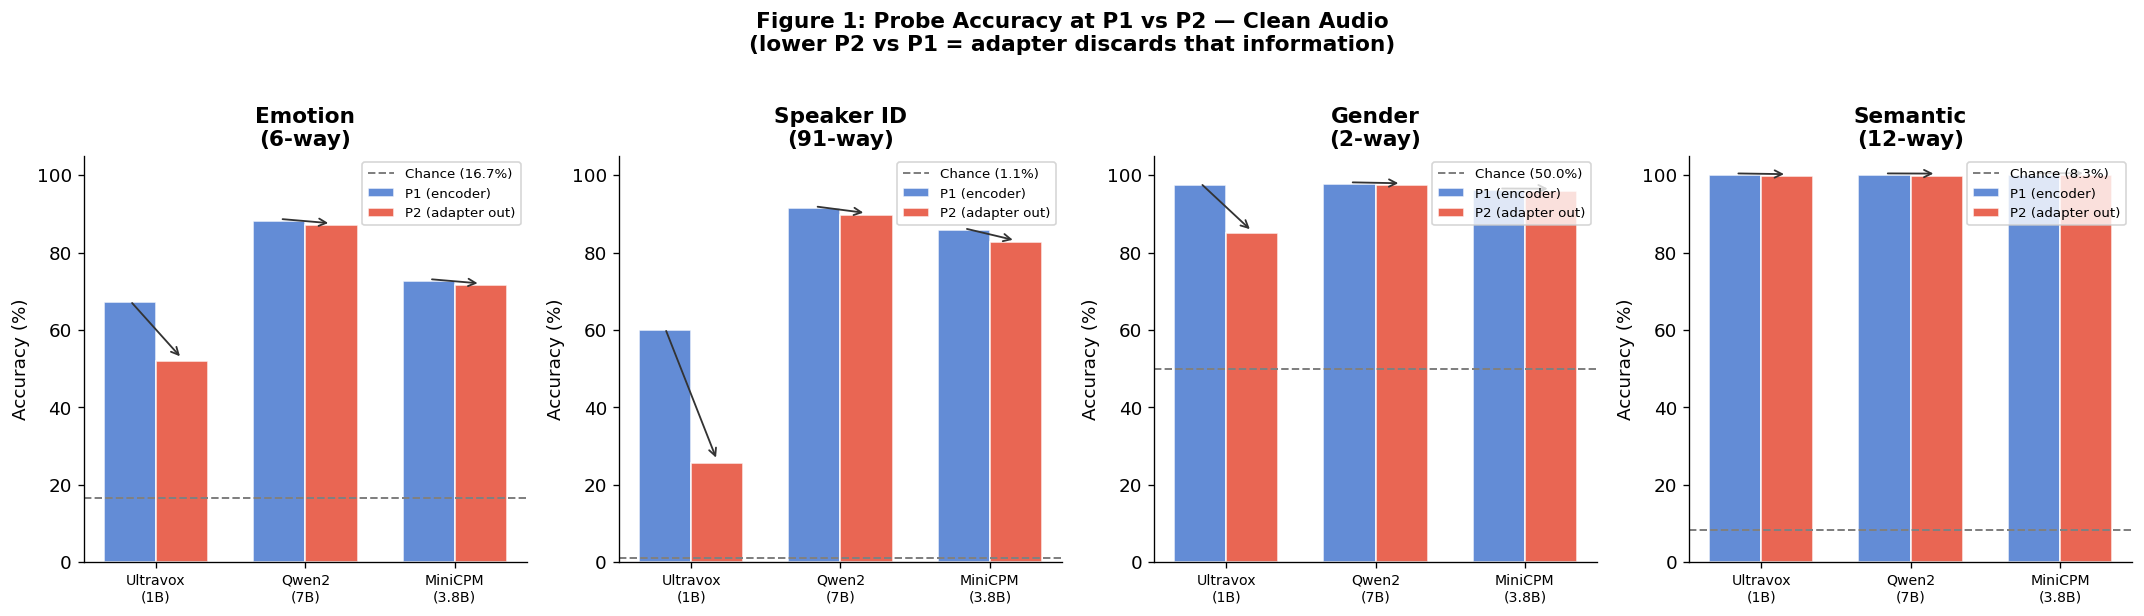

Saved fig1_p1_vs_p2_bars.png
Using JSON perturbation_probes for ultravox


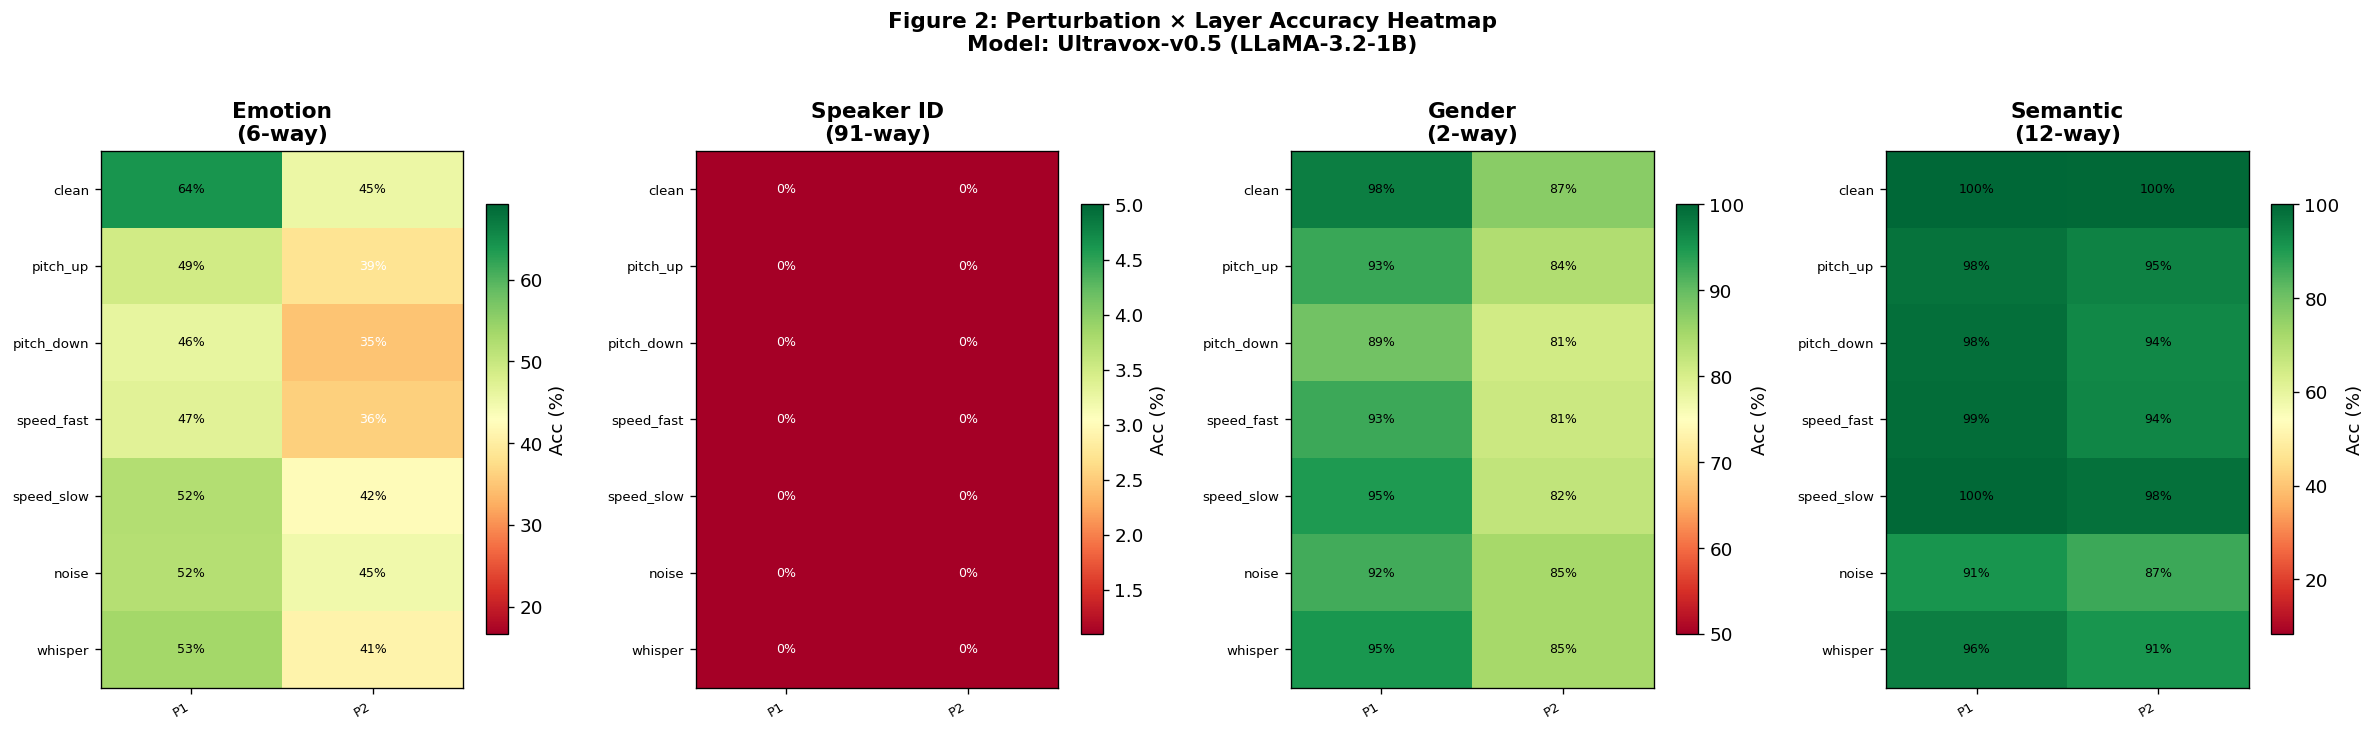

Saved fig2_perturbation_heatmap.png


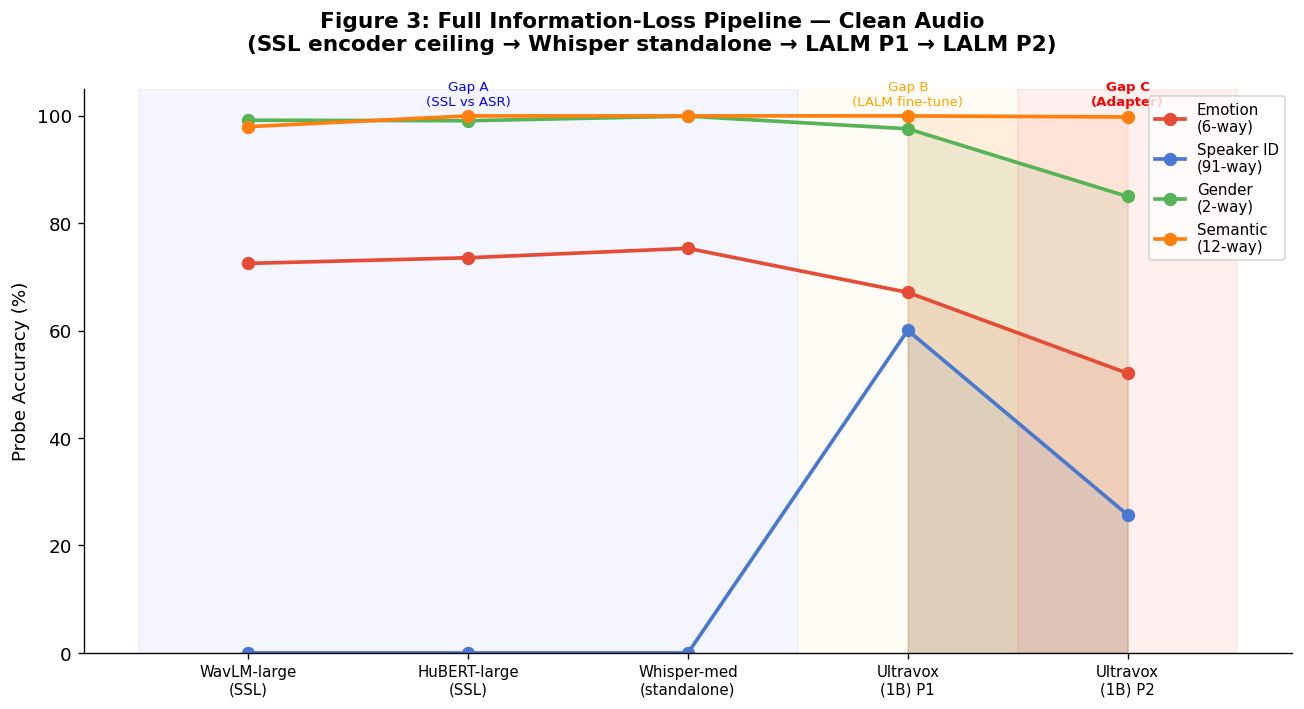

Saved fig3_pipeline_information_loss.png


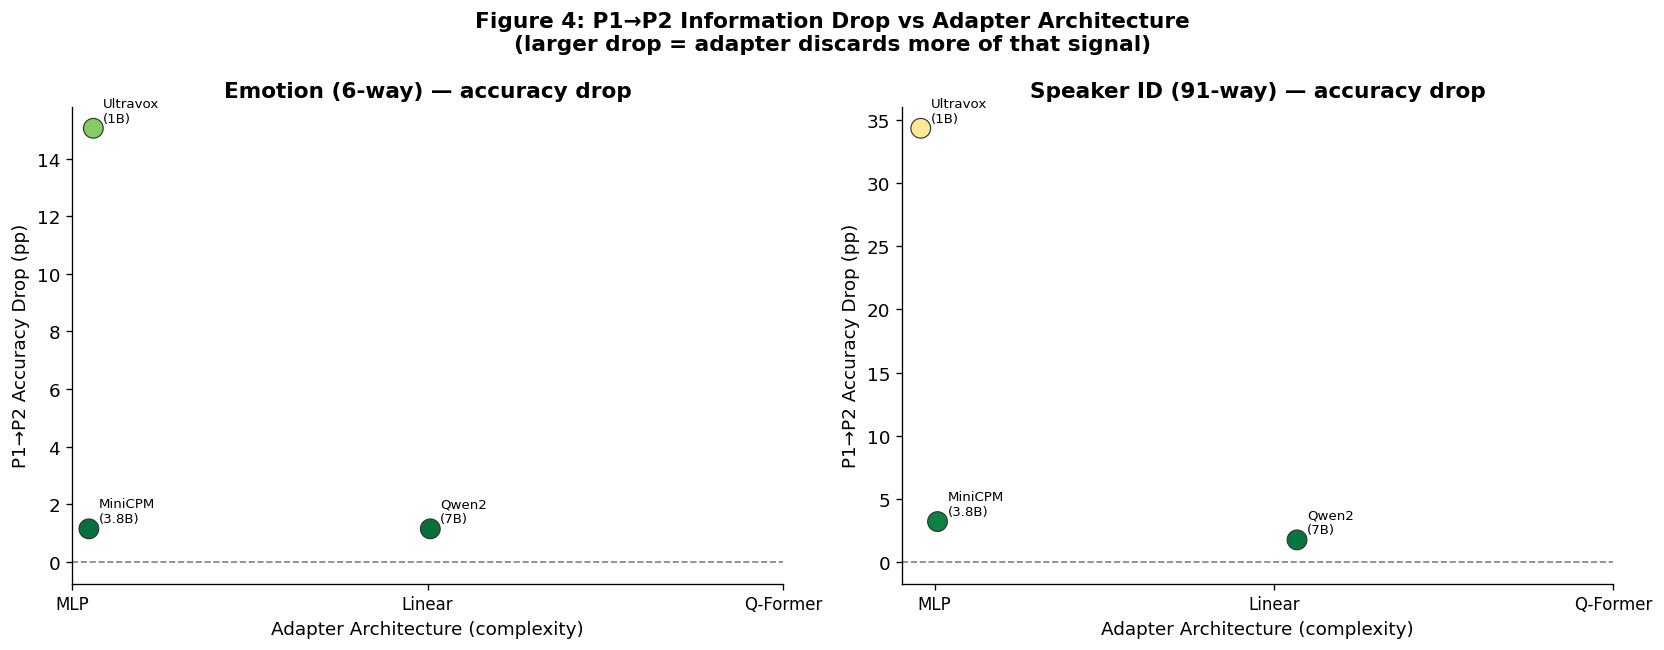

Saved fig4_drop_vs_adapter.png


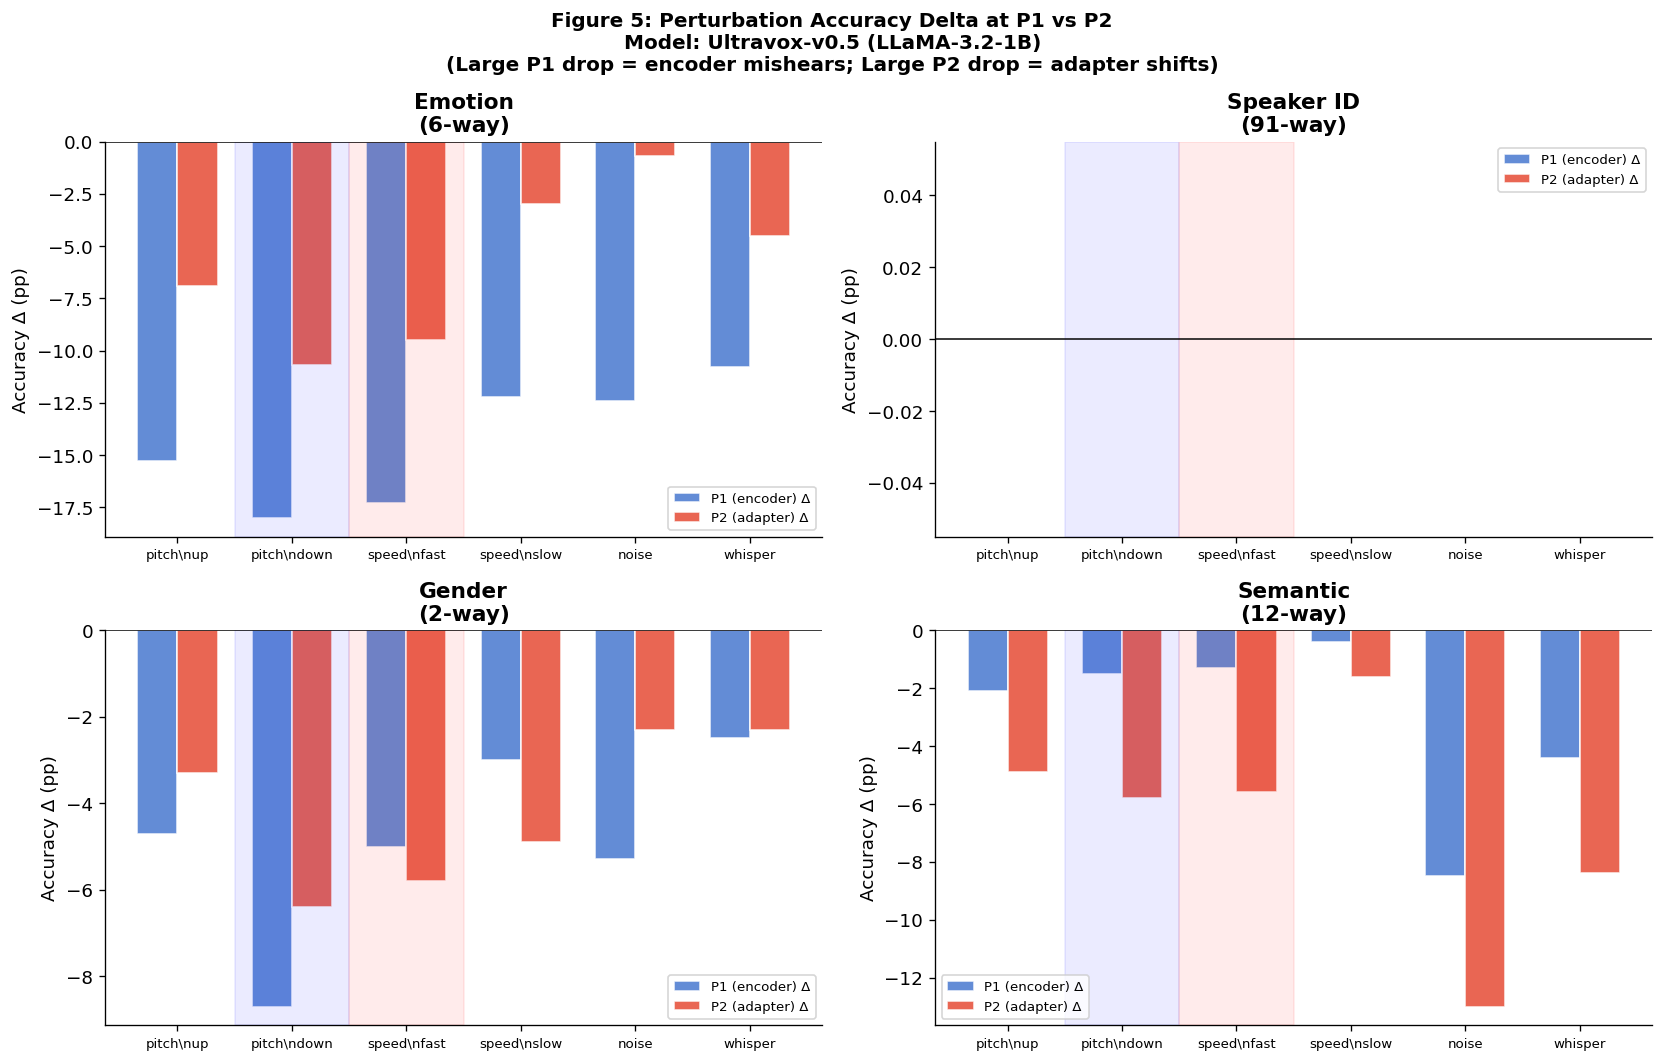

Saved fig5_perturbation_delta_p1_p2.png


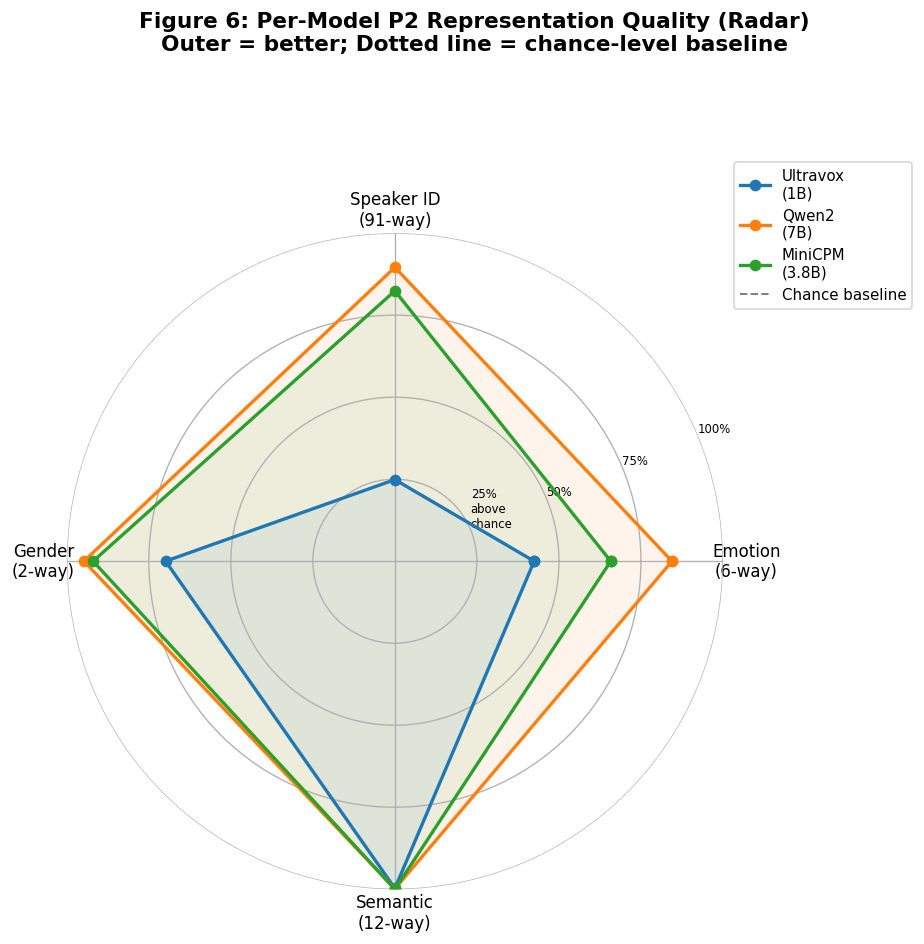

Saved fig6_radar_p2_quality.png

All figures complete.
PNG files saved in the working directory.
To use in LaTeX: \includegraphics[width=\linewidth]{fig1_p1_vs_p2_bars.png}


In [12]:


import json, math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

matplotlib.rcParams.update({
    'font.family':  'DejaVu Sans',
    'font.size':    11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi':   120,
    'savefig.dpi':  300,
    'savefig.bbox': 'tight',
})

C_P1    = '#4878CF'   # blue
C_P2    = '#E64B35'   # red-orange
C_LLM   = '#56B356'   # green
C_CLEAN = '#6A5ACD'   # slate-blue

TASK_META = {
    'emotion':  {'label': 'Emotion\n(6-way)',      'chance': 1/6,  'n': 6},
    'speaker':  {'label': 'Speaker ID\n(91-way)',  'chance': 1/91, 'n': 91},
    'gender':   {'label': 'Gender\n(2-way)',        'chance': 0.5,  'n': 2},
    'semantic': {'label': 'Semantic\n(12-way)',     'chance': 1/12, 'n': 12},
}
TASKS   = list(TASK_META.keys())
MODEL_KEYS = ['ultravox','qwen2','phi4','salmonn','diva','gemma3n','minicpm']
PERTURB_ORDER = ['clean','pitch_up','pitch_down','speed_fast','speed_slow','noise','whisper']
PERTURB_LABELS = ['clean','pitch\\nup','pitch\\ndown','speed\\nfast','speed\\nslow','noise','whisper']

# loading all available probe_results_*.json 
all_data = {}
for mk in MODEL_KEYS:
    p = Path(f'probe_results_{mk}.json')
    if p.exists():
        with open(p) as f:
            all_data[mk] = json.load(f)

if not all_data:
    print('[WARN] No probe_results_*.json files found.'
          '  Run Cells 10-12 for at least one model first.')
else:
    print(f'Loaded results for: {list(all_data.keys())}')

def short_name(mk):
    return {
        'ultravox': 'Ultravox\n(1B)', 'qwen2': 'Qwen2\n(7B)',
        'phi4':     'Phi-4\n(3.8B)',  'salmonn': 'SALMONN\n(7B)',
        'diva':     'DiVA\n(8B)',     'gemma3n': 'Gemma-3n\n(4B)',
        'minicpm':  'MiniCPM\n(3.8B)',
    }.get(mk, mk)

#   P1 vs P2 per model, per task
if all_data:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
    fig.suptitle('Figure 1: Probe Accuracy at P1 vs P2 — Clean Audio\n'
                 '(lower P2 vs P1 = adapter discards that information)',
                 fontsize=13, fontweight='bold', y=1.02)

    avail = [mk for mk in MODEL_KEYS if mk in all_data]
    x     = np.arange(len(avail))
    w     = 0.35

    for ax, task in zip(axes, TASKS):
        meta    = TASK_META[task]
        p1_vals = []
        p2_vals = []
        for mk in avail:
            cp = all_data[mk].get('clean_probes', {}).get(task, {})
            p1_vals.append(cp.get('P1', [0])[0] * 100 if 'P1' in cp else 0)
            p2_vals.append(cp.get('P2', [0])[0] * 100 if 'P2' in cp else 0)

        bars1 = ax.bar(x - w/2, p1_vals, w, label='P1 (encoder)',
                       color=C_P1, alpha=0.85, edgecolor='white')
        bars2 = ax.bar(x + w/2, p2_vals, w, label='P2 (adapter out)',
                       color=C_P2, alpha=0.85, edgecolor='white')

        # Annotate delta arrows
        for i, (v1, v2) in enumerate(zip(p1_vals, p2_vals)):
            if v1 > 0 and v2 > 0:
                ax.annotate('', xy=(x[i]+w/2, v2+0.5),
                            xytext=(x[i]-w/2, v1+0.5),
                            arrowprops=dict(arrowstyle='->', color='#333', lw=1.1))

        ax.axhline(meta['chance']*100, color='grey', ls='--', lw=1.2,
                   label=f'Chance ({meta["chance"]*100:.1f}%)')
        ax.set_title(meta['label'], fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([short_name(mk) for mk in avail], fontsize=8.5)
        ax.set_ylabel('Accuracy (%)')
        ax.set_ylim(0, 105)
        ax.legend(fontsize=8, loc='upper right')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('fig1_p1_vs_p2_bars.png')
    plt.show()
    print('Saved fig1_p1_vs_p2_bars.png')

#  Heatmap: perturbation × layer accuracy (per task)
try:
    _pr = PERTURB_RESULTS
    _active = ACTIVE_MODEL
    print(f'Using in-memory PERTURB_RESULTS for {_active}')
except NameError:
    _active = next(iter(all_data), None)
    _pr     = all_data[_active].get('perturbation_probes', {}) if _active else {}
    print(f'Using JSON perturbation_probes for {_active}')

if _pr and _active:
    layers_order = ['P1','P2','LLM_early','LLM_mid','LLM_late']

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    fig.suptitle(f'Figure 2: Perturbation × Layer Accuracy Heatmap\n'
                 f'Model: {all_data.get(_active, {}).get("model", _active)}',
                 fontsize=13, fontweight='bold', y=1.01)

    for ax, task in zip(axes, TASKS):
        meta    = TASK_META[task]
        avail_conds  = [c for c in PERTURB_ORDER if c in _pr]
        avail_layers = [l for l in layers_order
                        if any(l in _pr.get(c, {}).get(task, {}) for c in avail_conds)]

        mat = np.full((len(avail_conds), len(avail_layers)), np.nan)
        for ci, cond in enumerate(avail_conds):
            for li, layer in enumerate(avail_layers):
                v = _pr.get(cond, {}).get(task, {}).get(layer)
                if v is not None:
                    mat[ci, li] = (v[0] if isinstance(v, (list,tuple)) else v) * 100

        im = ax.imshow(mat, aspect='auto', cmap='RdYlGn',
                       vmin=meta['chance']*100, vmax=min(100, mat[~np.isnan(mat)].max()+5)
                       if not np.all(np.isnan(mat)) else 100)
        ax.set_xticks(range(len(avail_layers)))
        ax.set_xticklabels(avail_layers, fontsize=8, rotation=30, ha='right')
        ax.set_yticks(range(len(avail_conds)))
        ax.set_yticklabels(avail_conds, fontsize=8)
        ax.set_title(meta['label'], fontweight='bold')

        # Annotate cells
        for ci in range(len(avail_conds)):
            for li in range(len(avail_layers)):
                val = mat[ci, li]
                if not np.isnan(val):
                    ax.text(li, ci, f'{val:.0f}%', ha='center', va='center',
                            fontsize=7.5, color='black' if val > 40 else 'white')

        plt.colorbar(im, ax=ax, shrink=0.8, label='Acc (%)')

    plt.tight_layout()
    plt.savefig('fig2_perturbation_heatmap.png')
    plt.show()
    print('Saved fig2_perturbation_heatmap.png')

#  line plot: full information-loss pipeline
enc_path = Path('encoder_probe_results.json')
enc_data = {}
if enc_path.exists():
    with open(enc_path) as f:
        enc_data = json.load(f)

# ordered stage list for plotting
# Stages: WavLM → HuBERT → Whisper-med standalone → LALM P1 → LALM P2
PIPELINE_STAGES = [
    ('enc', 'wavlm_large',    'WavLM-large\n(SSL)'),
    ('enc', 'hubert_large',   'HuBERT-large\n(SSL)'),
    ('enc', 'whisper_medium', 'Whisper-med\n(standalone)'),
    ('lalm', 'P1',            f'{short_name(next(iter(all_data),""))} P1'),
    ('lalm', 'P2',            f'{short_name(next(iter(all_data),""))} P2'),
]

has_enc = bool(enc_data)
has_lalm = bool(all_data)

if has_enc or has_lalm:
    task_colors = {
        'emotion':  '#E64B35',
        'speaker':  '#4878CF',
        'gender':   '#56B356',
        'semantic': '#FF7F0E',
    }

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.suptitle('Figure 3: Full Information-Loss Pipeline — Clean Audio\n'
                 '(SSL encoder ceiling → Whisper standalone → LALM P1 → LALM P2)',
                 fontsize=13, fontweight='bold')

    stage_labels = []
    first_lalm   = next(iter(all_data), None)

    for task in TASKS:
        accs    = []
        x_pos   = []
        x_idx   = 0

        # Encoder stages
        for enc_key, label in [
            ('wavlm_large',    'WavLM-large\n(SSL)'),
            ('hubert_large',   'HuBERT-large\n(SSL)'),
            ('whisper_medium', 'Whisper-med\n(standalone)'),
        ]:
            val = enc_data.get(enc_key, {}).get('clean', {}).get(task)
            if val is not None:
                accs.append((val[0] if isinstance(val,(list,tuple)) else val)*100)
                x_pos.append(x_idx)
                if len(stage_labels) < x_idx+1:
                    stage_labels.append(label)
            x_idx += 1

        # LALM stages (P1, P2)
        if first_lalm:
            cp = all_data[first_lalm].get('clean_probes',{}).get(task,{})
            for layer_key, label in [('P1', f'{short_name(first_lalm)} P1'),
                                      ('P2', f'{short_name(first_lalm)} P2')]:
                val = cp.get(layer_key)
                if val is not None:
                    accs.append((val[0] if isinstance(val,(list,tuple)) else val)*100)
                    x_pos.append(x_idx)
                    if len(stage_labels) < x_idx+1:
                        stage_labels.append(label)
                x_idx += 1

        if len(x_pos) >= 2:
            ax.plot(x_pos, accs, 'o-', color=task_colors[task],
                    lw=2.2, ms=7, label=TASK_META[task]['label'].replace('\\n',' '))
            # Shade the P1->P2 adapter gap
            if len(x_pos) >= 2:
                ax.fill_between(x_pos[-2:], accs[-2:],
                                alpha=0.10, color=task_colors[task])

    ax.set_xticks(range(x_idx))
    ax.set_xticklabels(stage_labels[:x_idx], fontsize=9)
    ax.set_ylabel('Probe Accuracy (%)')
    ax.set_ylim(0, 105)

    # Annotate gap regions
    if x_idx >= 3:
        ax.axvspan(-0.5, 2.5, alpha=0.04, color='blue')
        ax.text(1.0, 102, 'Gap A\n(SSL vs ASR)', ha='center', fontsize=8, color='blue')
    if x_idx >= 4:
        ax.axvspan(2.5, 3.5, alpha=0.04, color='orange')
        ax.text(3.0, 102, 'Gap B\n(LALM fine-tune)', ha='center', fontsize=8, color='orange')
    if x_idx >= 5:
        ax.axvspan(3.5, 4.5, alpha=0.06, color='red')
        ax.text(4.0, 102, 'Gap C\n(Adapter)', ha='center', fontsize=8, color='red',
                fontweight='bold')

    ax.legend(fontsize=9, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig3_pipeline_information_loss.png')
    plt.show()
    print('Saved fig3_pipeline_information_loss.png')

#Scatter: P1->P2 drop vs adapter type
ADAPTER_COMPLEXITY = {
    'ultravox': (1, 'MLP\n(StackFrames)'),
    'minicpm':  (1, 'MLP\n(MiniCPM)'),
    'phi4':     (1, 'MLP\n(Phi-4)'),
    'gemma3n':  (1, 'MatFormer\nProjection'),
    'qwen2':    (2, 'Linear +\nLayerNorm'),
    'diva':     (2, 'Linear\n(distilled)'),
    'salmonn':  (3, 'Q-Former\n(32 tokens)'),
}

if len(all_data) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle('Figure 4: P1\u2192P2 Information Drop vs Adapter Architecture\n'
                 '(larger drop = adapter discards more of that signal)',
                 fontsize=13, fontweight='bold')

    for ax, task in zip(axes, ['emotion', 'speaker']):
        meta = TASK_META[task]
        scatter_x, scatter_y, scatter_labels = [], [], []

        for mk, data in all_data.items():
            cp  = data.get('clean_probes', {}).get(task, {})
            p1  = cp.get('P1')
            p2  = cp.get('P2')
            if p1 is None or p2 is None:
                continue
            p1_acc = (p1[0] if isinstance(p1,(list,tuple)) else p1)*100
            p2_acc = (p2[0] if isinstance(p2,(list,tuple)) else p2)*100
            drop = p1_acc - p2_acc
            complexity = ADAPTER_COMPLEXITY.get(mk, (1, mk))[0]
            scatter_x.append(complexity + np.random.uniform(-0.07, 0.07))
            scatter_y.append(drop)
            scatter_labels.append(short_name(mk).replace('\\n', ' '))

        if scatter_x:
            ax.scatter(scatter_x, scatter_y, s=140, zorder=5,
                       c=scatter_y, cmap='RdYlGn_r', vmin=0, vmax=60,
                       edgecolors='#333', linewidths=0.7)
            for xi, yi, lbl in zip(scatter_x, scatter_y, scatter_labels):
                ax.annotate(lbl, (xi, yi),
                            xytext=(6, 4), textcoords='offset points',
                            fontsize=8)

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['MLP', 'Linear', 'Q-Former'], fontsize=10)
        ax.set_xlabel('Adapter Architecture (complexity)')
        ax.set_ylabel('P1\u2192P2 Accuracy Drop (pp)')
        ax.set_title(f'{meta["label"].replace(chr(10), " ")} — accuracy drop', fontweight='bold')
        ax.axhline(0, color='grey', ls='--', lw=1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('fig4_drop_vs_adapter.png')
    plt.show()
    print('Saved fig4_drop_vs_adapter.png')

#  Perturbation Delta at P1 vs P2 (mechanism test)

if _pr and _active:
    conds = [c for c in PERTURB_ORDER if c in _pr and c != 'clean']
    clean_base = _pr.get('clean', {})

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f'Figure 5: Perturbation Accuracy Delta at P1 vs P2\n'
                 f'Model: {all_data.get(_active, {}).get("model", _active)}\n'
                 f'(Large P1 drop = encoder mishears; Large P2 drop = adapter shifts)',
                 fontsize=12, fontweight='bold')
    axes = axes.flatten()

    for ax, task in zip(axes, TASKS):
        meta = TASK_META[task]
        x    = np.arange(len(conds))
        w    = 0.35

        p1_deltas, p2_deltas = [], []
        for cond in conds:
            def _acc(cond_key, layer):
                v = _pr.get(cond_key, {}).get(task, {}).get(layer)
                return (v[0] if isinstance(v,(list,tuple)) else v)*100 if v else None

            base_p1 = _acc('clean', 'P1')
            base_p2 = _acc('clean', 'P2')
            cond_p1 = _acc(cond,    'P1')
            cond_p2 = _acc(cond,    'P2')

            p1_deltas.append(cond_p1 - base_p1 if (cond_p1 and base_p1) else 0)
            p2_deltas.append(cond_p2 - base_p2 if (cond_p2 and base_p2) else 0)

        bars1 = ax.bar(x - w/2, p1_deltas, w, label='P1 (encoder) Δ',
                       color=[C_P1 if d >= 0 else '#4878CF88' for d in p1_deltas],
                       alpha=0.85, edgecolor='white')
        bars2 = ax.bar(x + w/2, p2_deltas, w, label='P2 (adapter) Δ',
                       color=[C_P2 if d >= 0 else '#E64B3588' for d in p2_deltas],
                       alpha=0.85, edgecolor='white')

        ax.axhline(0, color='black', lw=0.9)

        # Highlight key conditions
        for i, cond in enumerate(conds):
            if cond == 'pitch_down':
                ax.axvspan(i-0.5, i+0.5, alpha=0.08, color='blue', label='_')
            if cond == 'speed_fast':
                ax.axvspan(i-0.5, i+0.5, alpha=0.08, color='red', label='_')

        ax.set_xticks(x)
        ax.set_xticklabels([c.replace('_', '\\n') for c in conds], fontsize=8)
        ax.set_ylabel('Accuracy Δ (pp)')
        ax.set_title(meta['label'], fontweight='bold')
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('fig5_perturbation_delta_p1_p2.png')
    plt.show()
    print('Saved fig5_perturbation_delta_p1_p2.png')

# Radar chart: per-model P2 quality across tasks
if len(all_data) >= 2:
    n_tasks  = len(TASKS)
    angles   = np.linspace(0, 2*np.pi, n_tasks, endpoint=False).tolist()
    angles  += angles[:1]  # close the loop

    task_labels = [TASK_META[t]['label'].replace('\\n','\n') for t in TASKS]

    fig, ax = plt.subplots(figsize=(8, 8),
                           subplot_kw=dict(polar=True))
    fig.suptitle('Figure 6: Per-Model P2 Representation Quality (Radar)\n'
                 'Outer = better; Dotted line = chance-level baseline',
                 fontsize=13, fontweight='bold', y=1.02)

    cmap = plt.get_cmap('tab10')
    avail = [mk for mk in MODEL_KEYS if mk in all_data]

    for i, mk in enumerate(avail):
        vals = []
        for task in TASKS:
            cp  = all_data[mk].get('clean_probes',{}).get(task,{})
            p2  = cp.get('P2')
            acc = (p2[0] if isinstance(p2,(list,tuple)) else p2)*100 if p2 else 0
            # normalise to [0,1] relative to chance and 100%
            chance = TASK_META[task]['chance']*100
            norm   = (acc - chance) / (100 - chance) if acc > chance else 0
            vals.append(max(0, norm))
        vals += vals[:1]
        color = cmap(i)
        ax.plot(angles, vals, 'o-', lw=2, color=color, label=short_name(mk).replace('\\n',' '))
        ax.fill(angles, vals, alpha=0.08, color=color)

    # Chance ring
    ax.plot(angles, [0]*len(angles), '--', color='grey', lw=1.2, label='Chance baseline')

    ax.set_thetagrids(np.degrees(angles[:-1]), task_labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%\nabove\nchance', '50%', '75%', '100%'], fontsize=7)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.12), fontsize=9)
    ax.spines['polar'].set_visible(False)

    plt.tight_layout()
    plt.savefig('fig6_radar_p2_quality.png')
    plt.show()
    print('Saved fig6_radar_p2_quality.png')

print('\nAll figures complete.')
print('PNG files saved in the working directory.')
print('To use in LaTeX: \\includegraphics[width=\\linewidth]{fig1_p1_vs_p2_bars.png}')
